In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pykalman
from scipy import stats
from tqdm import tqdm
import matplotlib.ticker as ticker
from scipy.stats import norm
import seaborn as sns

In [194]:
def sm_simulation(T, dt=0.1, P=0, M=0.5):
    np.random.seed(200)
    
    timesteps = np.arange(0, T, dt) ; duration=len(timesteps)

    s = np.zeros(duration)
    m = np.zeros(duration)
    omega=(2*np.pi)/24


    # Use von Mises for circular noise
    kappa_p = 1 / P**2 if P > 0 else 0
    kappa_m = 1 / M**2 if M > 0 else 0

    true_process_noise = np.random.vonmises(mu=0, kappa=kappa_p, size=duration) if P > 0 else np.zeros(duration)
    measurement_noise = np.random.normal(loc=0, scale=M, size=duration) if M > 0 else np.zeros(duration)


    for t in range(duration):
        if t==0:
            s[0] = 0
        else:
            s[t] = np.angle(np.exp(1j * (s[t-1] + omega*dt)) * np.exp(1j * true_process_noise[t]))
        
        m[t] = np.sin(s[t]) + measurement_noise[t]

        s[t] = np.mod(s[t]+np.pi, 2 * np.pi)-np.pi
    return s, m



def Kalman_filter(T, m, dt=0.1,
                  init_mean=0, init_cov=0.1,
                  P_prime=0.1, M=0.5):

    np.random.seed(200)

    timesteps = np.arange(0, T, dt)
    duration = len(timesteps)

    # Angular frequency [rad/hour]
    omega = 2 * np.pi / 24  

    mu_post = np.zeros(duration)
    sigma2_post = np.zeros(duration)

    sigma2_process = P_prime**2
    sigma2_obs = M**2

    for t in range(duration):
        if t == 0:
            mu_prev = init_mean
            sigma2_prev = init_cov
        else:
            mu_prev = mu_post[t-1]
            sigma2_prev = sigma2_post[t-1]

        # === Predict ===
        mu_prior = mu_prev + omega * dt
        mu_prior = (mu_prior + np.pi) % (2*np.pi) - np.pi
        sigma2_prior = sigma2_prev + sigma2_process

        # === Update ===
        inv_sigma2_post = 1 / sigma2_prior + 1 / sigma2_obs
        sigma2_post[t] = 1 / inv_sigma2_post

        H = np.cos(mu_prior)
        G = H * sigma2_prior / (H * sigma2_prior * H + sigma2_obs)

        # Apply correction once (discrete style)
        mu = mu_prior + G * (m[t] - np.sin(mu_prior))
        mu = (mu + np.pi) % (2*np.pi) - np.pi

        mu_post[t] = mu

    return mu_post, sigma2_post


In [1]:
def count_phase_jumps(timesteps, angular_diff, time_gap=0.6, threshold=10, dt=0.1, summary=False):
    dtheta_dt = np.gradient(angular_diff, dt) #wrapped!!!
    dtheta_dt = np.asarray(dtheta_dt)  #convert to nparray for list indexing    
    abs_dtheta_dt = np.abs(dtheta_dt)
    jump_indices = np.where(abs_dtheta_dt > threshold)[0]

    # === STEP 3: Cluster jump indices based on index distance (not time) ===
    min_index_gap = int(time_gap/dt)  #HR
    clustered_jump_indices = []

    if len(jump_indices) > 0:
        current_cluster = [jump_indices[0]]

        for idx in jump_indices[1:]:
            if idx - current_cluster[-1] <= min_index_gap:
                current_cluster.append(idx)
            else:
                # Pick most extreme point in cluster
                best_idx = current_cluster[np.argmin(dtheta_dt[current_cluster])]
                clustered_jump_indices.append(best_idx)
                current_cluster = [idx]

        # Add last cluster
        if current_cluster:
            best_idx = current_cluster[np.argmin(dtheta_dt[current_cluster])]
            clustered_jump_indices.append(best_idx)

    # === STEP 4: Print results ===
    if summary:
        jump_times_days = np.floor(timesteps[clustered_jump_indices] / 24).astype(int)
        jump_times_hrs = np.round(timesteps[clustered_jump_indices]  % 24, 2)
        print(f"📌 Final jump count: {len(clustered_jump_indices)}")
        for ind in range(len(jump_times_days)):
            if ind==0:
                print("🕒 Jump times:")
                print(f"{jump_times_days[ind]} Day + {jump_times_hrs[ind]} Hr")
            else:
                print(f"{jump_times_days[ind]} Day + {jump_times_hrs[ind]} Hr")
            
     # === STEP 5: Create and return plot ===
    fig, ax = plt.subplots(figsize=(15, 4))
    ax.plot(timesteps / 24, dtheta_dt, color='brown', label='1st Derivative')
    ax.scatter(timesteps[clustered_jump_indices] / 24,
               dtheta_dt[clustered_jump_indices],
               color='red', label='Phase Jumps')
    ax.axhline(threshold, ls='--', color='gray', alpha=0.5, label='Threshold')
    ax.axhline(-threshold, ls='--', color='gray', alpha=0.5)
    ax.set_title("Detected Phase Jumps in Derivative")
    ax.set_xlabel("Time (days)")
    ax.set_ylabel("dθ/dt")
    ax.legend()
    plt.tight_layout()

    plt.close(fig)
    return fig, ax, clustered_jump_indices

$\text{underlying dynamics}\\[6pt]
s:~\Phi_t = \Phi_{t-1} + \omega + \zeta_t, \quad \omega = \dfrac{2 \pi}{24}, \quad \zeta_t \sim \mathcal{N}(0, P^2)\\[5pt]
m:L_t = \sin(\Phi_t) + \eta_t, \quad \eta_t \sim \mathcal{N}(0, M^2) \\[5pt]
$


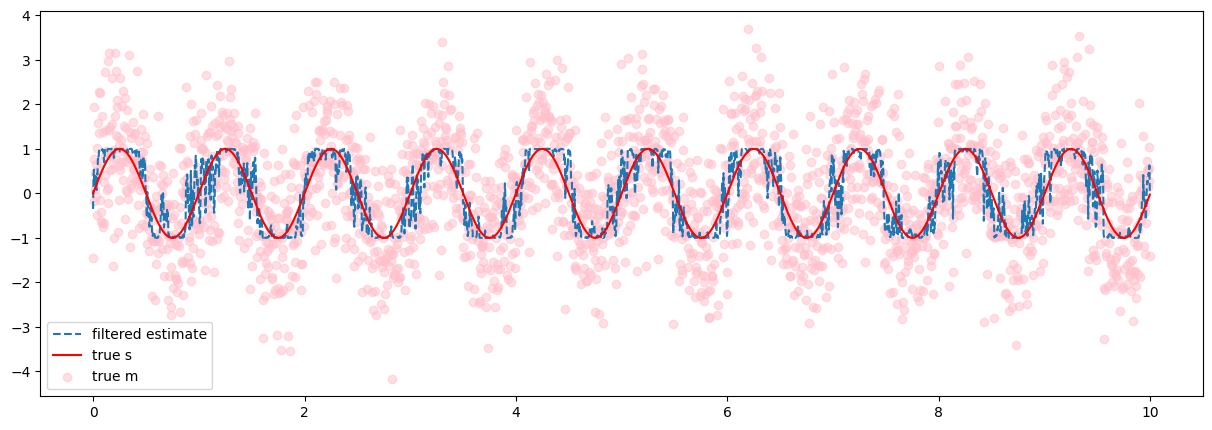

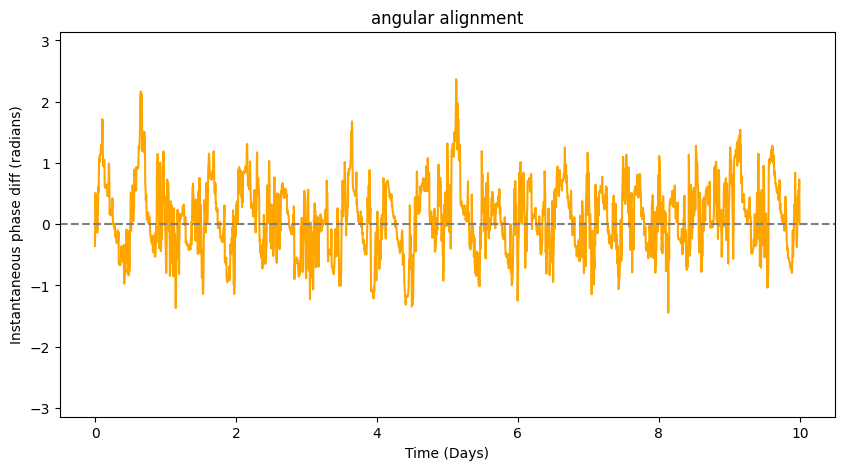

In [198]:
#testing Kalman framework
T=24*10 ; dt=0.1; timesteps=np.arange(0,T,dt)
s, m = sm_simulation(T=T, dt=dt, P=0, M=1)
mu_post, sigma2_post = Kalman_filter(T=T, dt=dt, m=m, init_mean=0, init_cov=0.1, P_prime=0.5, M=1)




#PLOT 1
plt.figure(figsize=(15,5))
plt.plot(timesteps/24, np.sin(mu_post), label='filtered estimate', linestyle='--')
plt.plot(timesteps/24, np.sin(s), label='true s', color='red')
plt.scatter(timesteps/24, m, color='pink', alpha=0.5, label='true m')
plt.legend()

# Plot2
plt.figure(figsize=(10,5))
angular_diff = np.angle(np.exp(1j * (mu_post - s))) 

plt.plot(timesteps/24, angular_diff, color='orange') 
plt.ylabel('Instantaneous phase diff (radians)')
plt.xlabel('Time (Days)')
plt.axhline(y=0, color='gray', linestyle='--')
plt.title('angular alignment')
plt.ylim(-np.pi,np.pi)
plt.show();

📌 Final jump count: 0


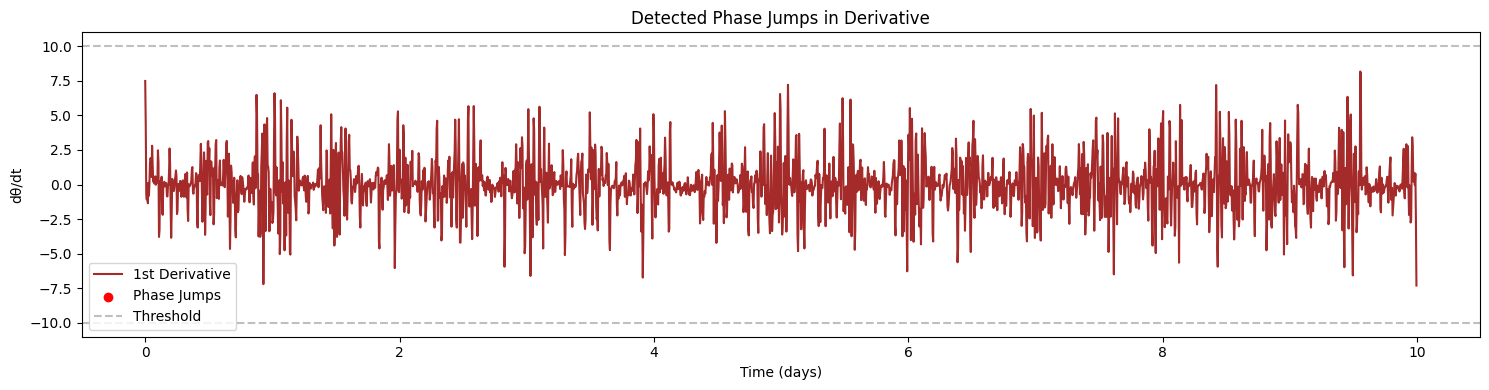

In [196]:
fig, axs, spikes = count_phase_jumps(timesteps, angular_diff)

### $\text{w/o Coupling}$

In [206]:
np.random.seed(200)
N = 100
T = 24*10 ; dt = 0.1 ; timesteps = np.arange(0, T, dt) ; duration=len(timesteps)

mean_period=23.5
std_period = 2



init_cov = 0.1

P_prime=0.05
P=0
M=5

s,m = sm_simulation(T=T, dt=dt, P=P, M=M)

var_p = P_prime**2
var_m = M**2


var_prior=np.zeros(duration)
var_post=np.zeros(duration)
G=np.zeros(duration)



################## SCN filter init ###################
phase_history = np.zeros((N, duration))
psi = np.zeros(duration)
r   = np.zeros(duration)

#g(ω)～N(loc,scale**2)
omega = np.random.normal(loc=2 * np.pi / mean_period, scale=(2 * np.pi / mean_period**2)*std_period, size=N) #g(ω)~N(loc,scale**2)


kappa_p_prime = 1 / P_prime**2 if P_prime > 0 else 0
xi = np.random.vonmises(mu=0, kappa=kappa_p_prime, size=(duration, N)) if P_prime > 0 else np.zeros((duration, N)) #xi=np.random.normal(loc=0, scale=P_prime, size=(duration,N))


for t in tqdm(range(duration), desc="simulating", ncols=80):

    if t==0:
        phases =  np.random.vonmises(0, kappa=0.1, size=N)        #phases = np.random.uniform(-np.pi, np.pi, N)

        var_prev=init_cov 
    else:
        var_prev=var_post[t-1]
    
    phase_history[:, t]=phases

    order_param = np.mean(np.exp(1j * phases)); '->np.mean(complex number) = np.ang + np.abs'
    r[t] = np.abs(order_param)
    psi[t] = np.angle(order_param)


    var_prior[t] = var_prev + var_p
    inv_var_post = 1 / var_prior[t] + 1 / var_m
    var_post[t] = 1 / inv_var_post   

    if t < (duration-1):

        for i in range(N):

            H = np.cos(phases[i]+omega[i])
            gap = m[t] - np.sin(phases[i]+omega[i])
            G = H*var_prior[t]/ (H*var_prior[t]*H + var_m)
            
            phases[i] += omega[i]* dt + xi[t,i] + G*gap
    
        phases = np.mod(phases+np.pi, 2 * np.pi)-np.pi

np.savez('EKF_EZ_NC.npz', omega=omega, xi=xi, init_phases=phase_history[:, 0], his_phase_nc=phase_history)

simulating: 100%|█████████████████████████| 2400/2400 [00:00<00:00, 2695.12it/s]


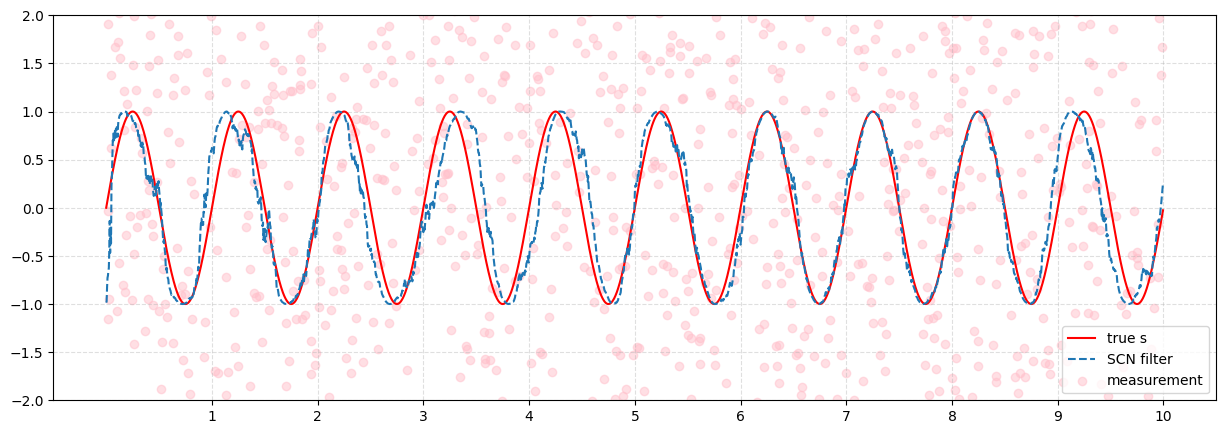

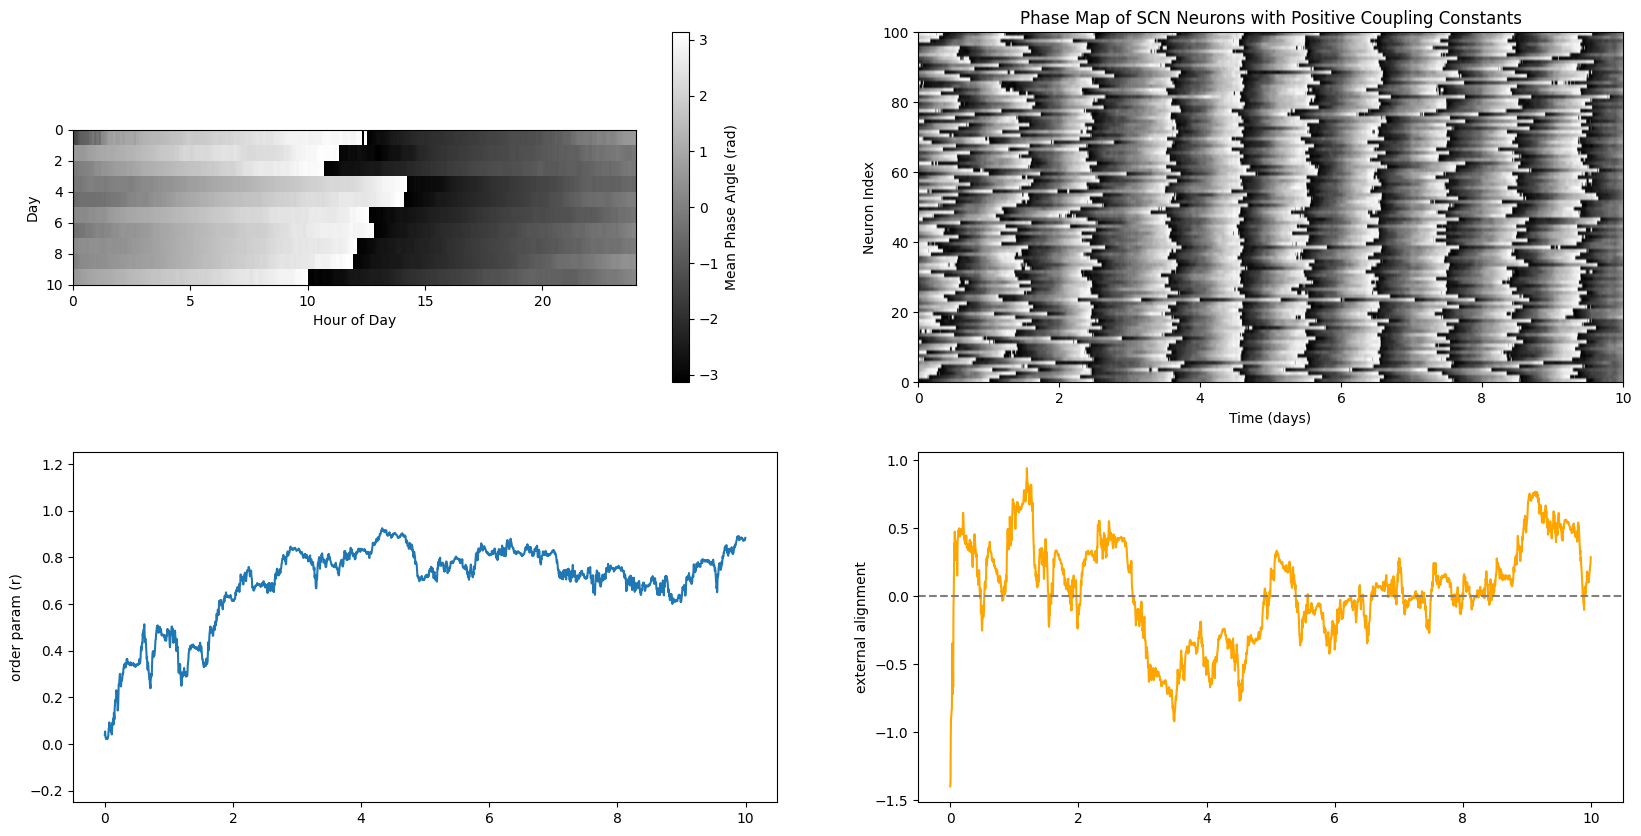

In [207]:
num_days = int(T / 24)

plt.figure(figsize=(15,5))
plt.plot(timesteps/24, np.sin(s), color='red', label='true s')
plt.plot(timesteps/24, np.sin(psi), label='SCN filter', linestyle='--')
plt.scatter(timesteps/24, m, alpha=0.5, color='pink', label='measurement')
plt.xticks(range(1,num_days+1))
plt.grid(True, linestyle='--', alpha=0.4)
plt.ylim(-2,2)
plt.legend()


fig, axs = plt.subplots(2, 2, figsize=(20, 10))

num_days = int(T / 24)
steps_per_day = int(24 / dt)
psi_2d = psi[:].reshape(num_days, steps_per_day)

im=axs[0,0].imshow(
    psi_2d,
    aspect=0.66,
    origin='lower',
    extent=[0, 24, 0, num_days],
    cmap='grey',  # or any other colormap 
    interpolation= 'none'  # or 'none'
)

axs[0,0].invert_yaxis()
axs[0,0].set_xlabel('Hour of Day')
axs[0,0].set_ylabel('Day')
cbar = fig.colorbar(im, ax=axs[0,0], label='Mean Phase Angle (rad)')

phase_norm = (phase_history / (2 * np.pi)) * 255  # Normalize phase to grayscale (0-255)
axs[0,1].imshow(phase_norm, aspect='auto', cmap='gray', origin='lower', extent=[0, T / 24, 0, N])
axs[0,1].set_xlabel('Time (days)')
axs[0,1].set_ylabel('Neuron Index')
axs[0,1].set_title('Phase Map of SCN Neurons with Positive Coupling Constants')


axs[1,0].plot(timesteps/24,r)
axs[1,0].set_ylabel('order param (r)')
axs[1,0].set_ylim(-0.25,1.25)


angular_diff1 = np.angle(np.exp(1j * (psi - s))) 
axs[1,1].plot(timesteps/24, np.unwrap(angular_diff1), color='orange') 
axs[1,1].set_ylabel('external alignment')
#axs[1,1].set_ylim(-np.pi, np.pi)
axs[1,1].axhline(y=0, color='gray', linestyle='--');

📌 Final jump count: 0


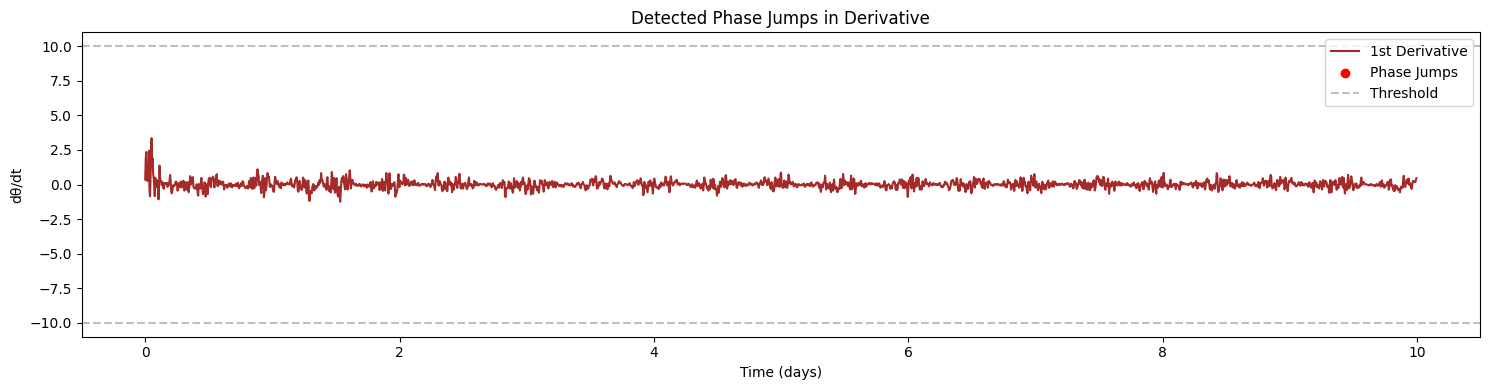

In [208]:
fig, ax, spikes = count_phase_jumps(timesteps, angular_diff1)

plt.show()

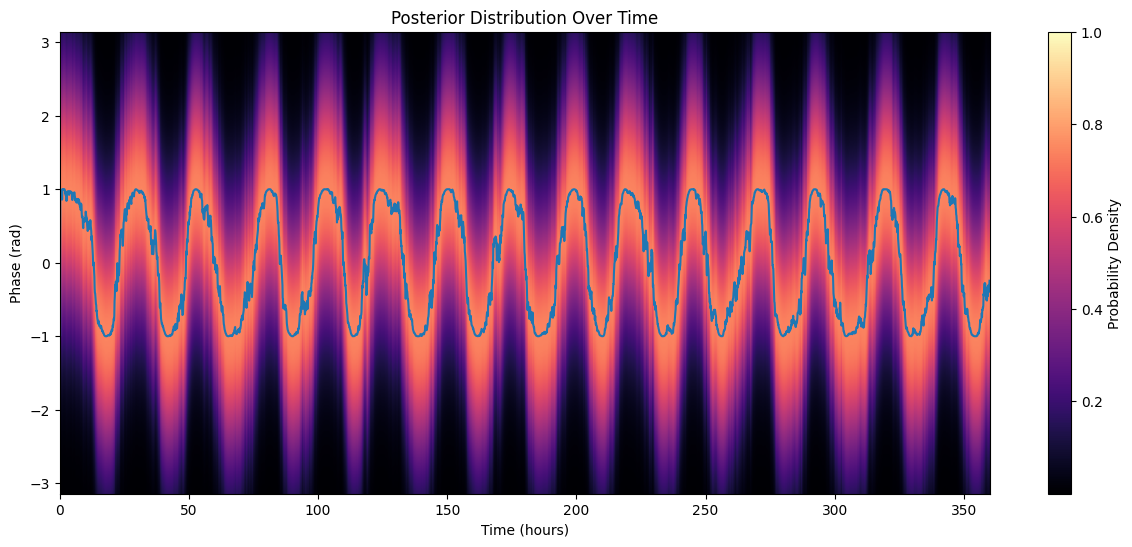

In [171]:
x = np.linspace(-np.pi, np.pi, 300)
pdf_grid = np.zeros((duration, len(x)))

# Fill heatmap
for t in range(duration):
    mu = np.sin(psi[t])
    sigma = np.sqrt(var_post[t])
    pdf_grid[t, :] = norm.pdf(x, loc=mu, scale=sigma)

# Normalize if you want
pdf_grid /= pdf_grid.max()

# Plot heatmap
plt.figure(figsize=(15, 6))
plt.imshow(pdf_grid.T, aspect='auto', origin='lower',
           extent=[0, T, -np.pi, np.pi], cmap='magma')
plt.plot(timesteps,np.sin(psi))
plt.xlabel("Time (hours)")
plt.ylabel("Phase (rad)")
plt.title("Posterior Distribution Over Time")
plt.colorbar(label="Probability Density")
plt.show()

### $\text{w/ Coupling}$

In [174]:
np.random.seed(200)

data=np.load('EKF_EZ_NC.npz')



N = 100
T = 24*5 ; dt = 0.1 ; timesteps = np.arange(0, T, dt) ; duration=len(timesteps)

mean_period=23.5
std_period = 2





init_cov = 0.1

P_prime=1
P=0
M=7

s,m = sm_simulation(T=T, dt=dt, P=P, M=M)

var_p = P_prime**2
var_m = M**2

var_prior=np.zeros(duration)
var_post=np.zeros(duration)
G=np.zeros(duration)



################## SCN filter init ###################
phase_history = np.zeros((N, duration))
psi2 = np.zeros(duration)
r2  = np.zeros(duration)

#g(ω)～N(loc,scale**2)
omega = data['omega']


K_matrix = np.random.uniform(0, 2, (N, N))
K_matrix = (K_matrix + K_matrix.T) / 2
np.fill_diagonal(K_matrix, 0)


kappa_p_prime = 1 / P_prime**2 if P_prime > 0 else 0
xi = data['xi']


for t in tqdm(range(duration), desc="simulating", ncols=80):

    if t==0:
        phases =  data['init_phases']

        var_prev=init_cov 
    else:
        var_prev=var_post[t-1]
    
    phase_history[:, t]=phases

    order_param = np.mean(np.exp(1j * phases)); '->np.mean(complex number) = np.ang + np.abs'
    r2[t] = np.abs(order_param)
    psi2[t] = np.angle(order_param)


    var_prior[t] = var_prev + var_p
    inv_var_post = 1 / var_prior[t] + 1 / var_m
    var_post[t] = 1 / inv_var_post   

    if t < (duration-1):

        for i in range(N):

            H = np.cos(phases[i]+omega[i])
            gap = m[t]-np.sin(phases[i]+omega[i])
            G = H*var_prior[t]/ (H*var_prior[t]*H + var_m)
            
            coupling_sum = 0
            for j in range(N):
                coupling_sum += K_matrix[i,j] * np.sin(phases[j] - phases[i])

            phases[i] += (omega[i] + xi[t,i] + G*gap + (1/N)*coupling_sum) * dt
    
        phases = np.mod(phases+np.pi, 2 * np.pi)-np.pi


simulating: 100%|███████████████████████████| 1200/1200 [00:15<00:00, 79.41it/s]


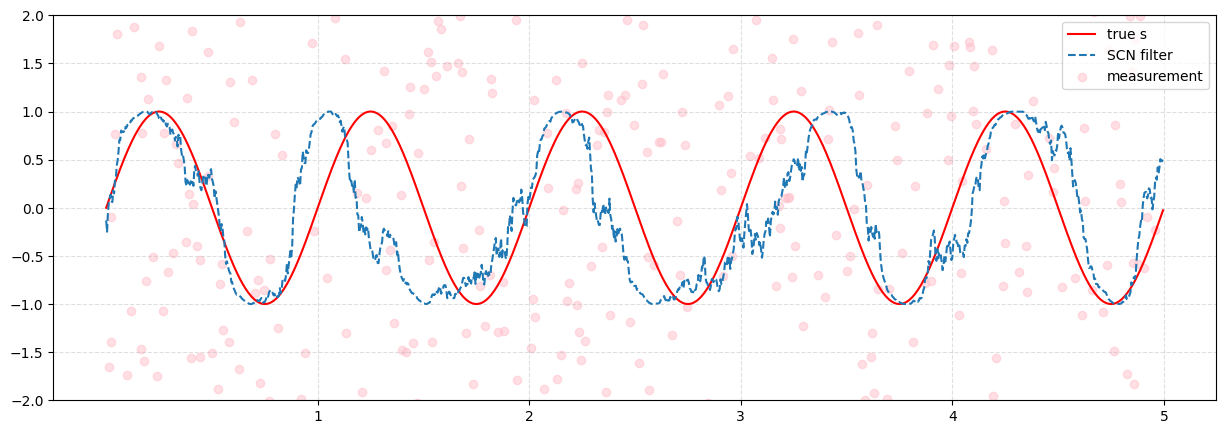

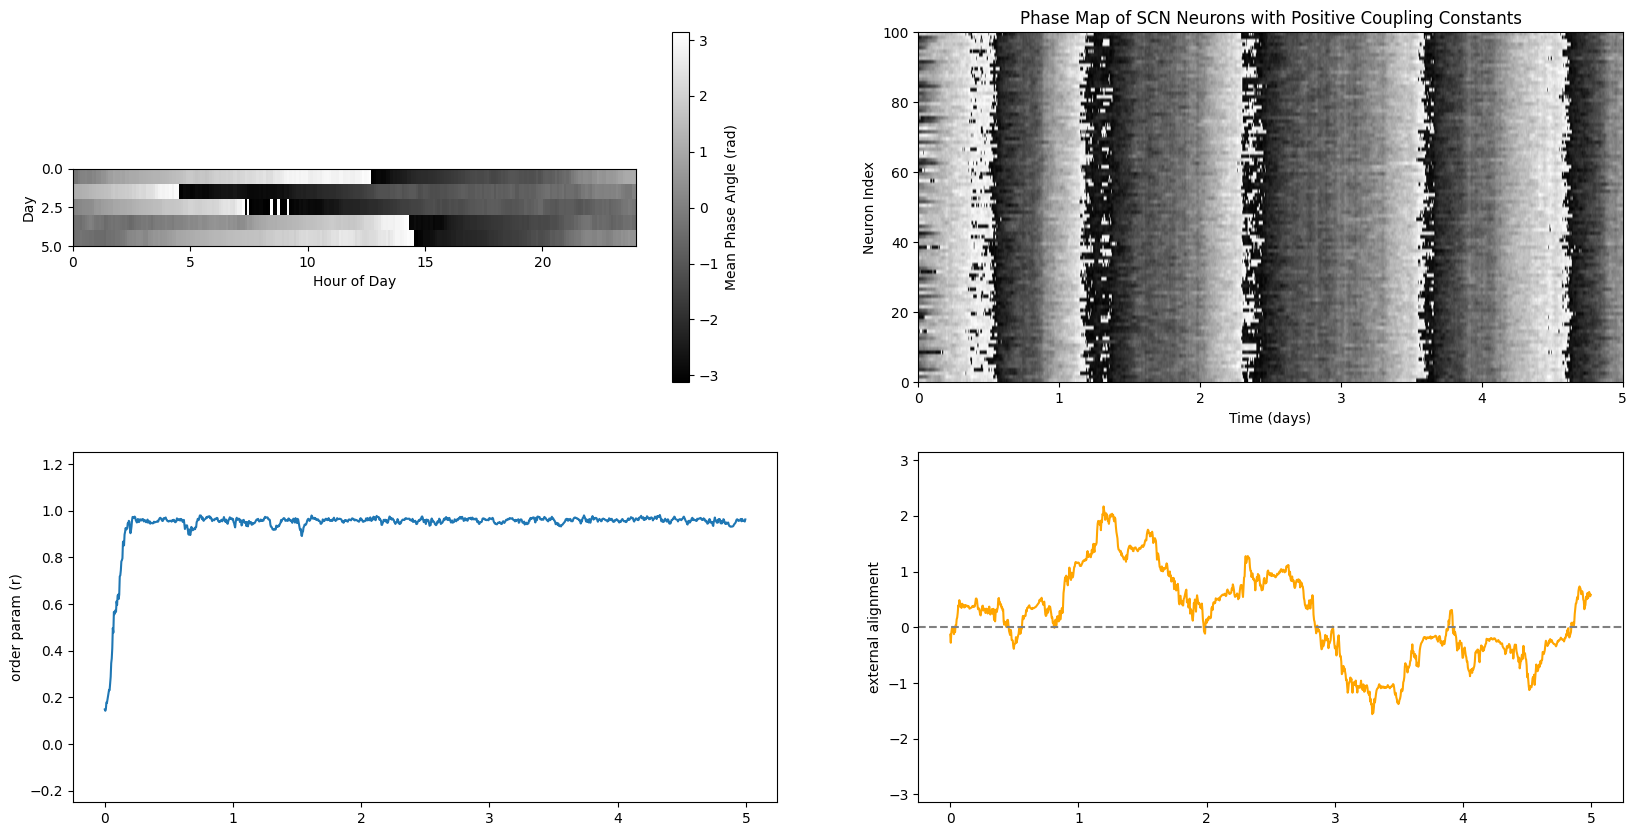

In [175]:
num_days = int(T / 24)

plt.figure(figsize=(15,5))
plt.plot(timesteps/24, np.sin(s), color='red', label='true s')
plt.plot(timesteps/24, np.sin(psi2), label='SCN filter', linestyle='--')
plt.scatter(timesteps/24, m, alpha=0.5, color='pink', label='measurement')
plt.xticks(range(1,num_days+1))
plt.grid(True, linestyle='--', alpha=0.4)
plt.ylim(-2,2)
plt.legend()


fig, axs = plt.subplots(2, 2, figsize=(20, 10))

num_days = int(T / 24)
steps_per_day = int(24 / dt)
psi_2d = psi2[:].reshape(num_days, steps_per_day)

im=axs[0,0].imshow(
    psi_2d,
    aspect=0.66,
    origin='lower',
    extent=[0, 24, 0, num_days],
    cmap='grey',  # or any other colormap 
    interpolation= 'none'  # or 'none'
)

axs[0,0].invert_yaxis()
axs[0,0].set_xlabel('Hour of Day')
axs[0,0].set_ylabel('Day')
cbar = fig.colorbar(im, ax=axs[0,0], label='Mean Phase Angle (rad)')

phase_norm = (phase_history / (2 * np.pi)) * 255  # Normalize phase to grayscale (0-255)
axs[0,1].imshow(phase_norm, aspect='auto', cmap='gray', origin='lower', extent=[0, T / 24, 0, N])
axs[0,1].set_xlabel('Time (days)')
axs[0,1].set_ylabel('Neuron Index')
axs[0,1].set_title('Phase Map of SCN Neurons with Positive Coupling Constants')


axs[1,0].plot(timesteps/24,r2)
axs[1,0].set_ylabel('order param (r)')
axs[1,0].set_ylim(-0.25,1.25)


angular_diff = np.angle(np.exp(1j * (psi2 - s))) 
axs[1,1].plot(timesteps/24, np.unwrap(angular_diff), color='orange') 
axs[1,1].set_ylabel('external alignment')
axs[1,1].set_ylim(-np.pi, np.pi)
axs[1,1].axhline(y=0, color='gray', linestyle='--');

NameError: name 'r2' is not defined

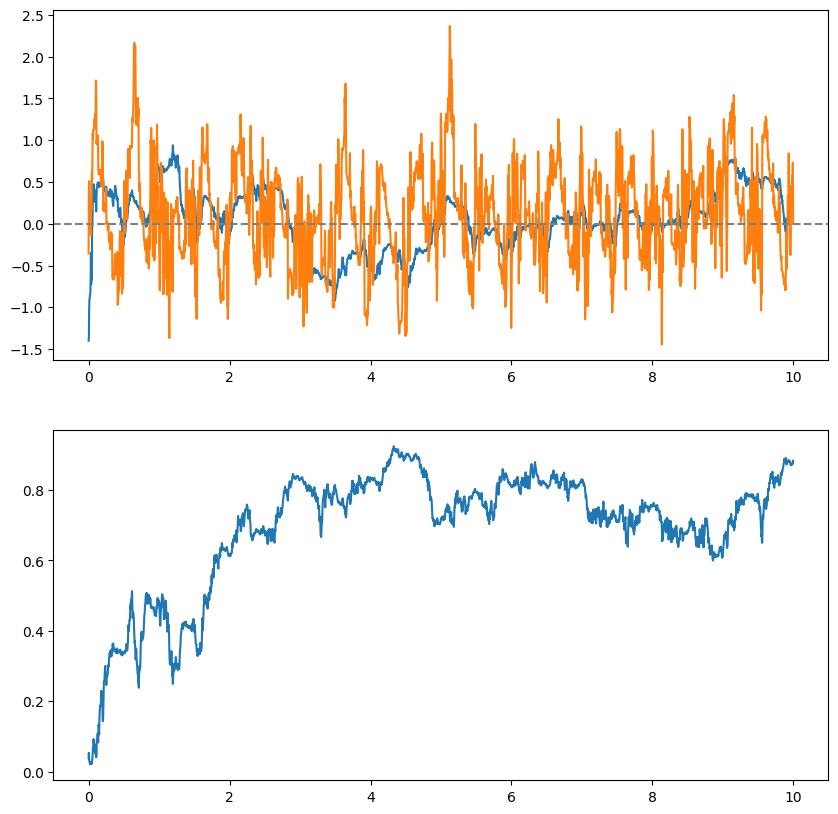

In [209]:
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

axs[0].plot(timesteps/24, np.unwrap(angular_diff1)) #psi-s
axs[0].plot(timesteps/24, np.unwrap(angular_diff)) #psi2-s
axs[0].axhline(y=0, c='gray', linestyle='--')

axs[1].plot(timesteps/24, r)
axs[1].plot(timesteps/24, r2);

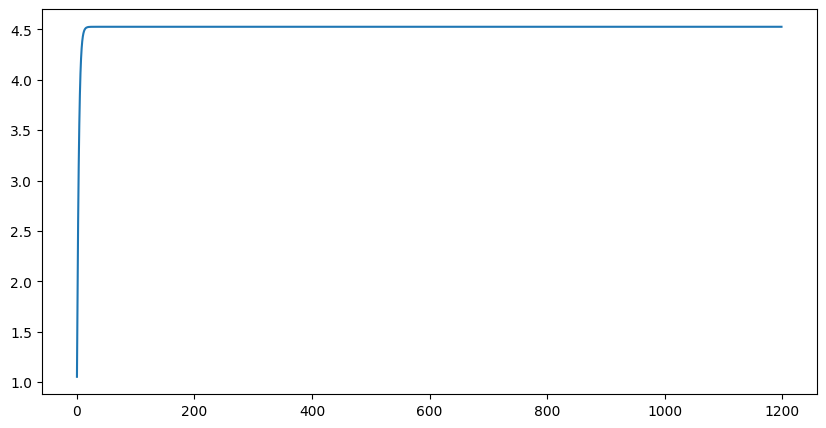

In [148]:
plt.figure(figsize=(10, 5))
plt.plot(var_post);

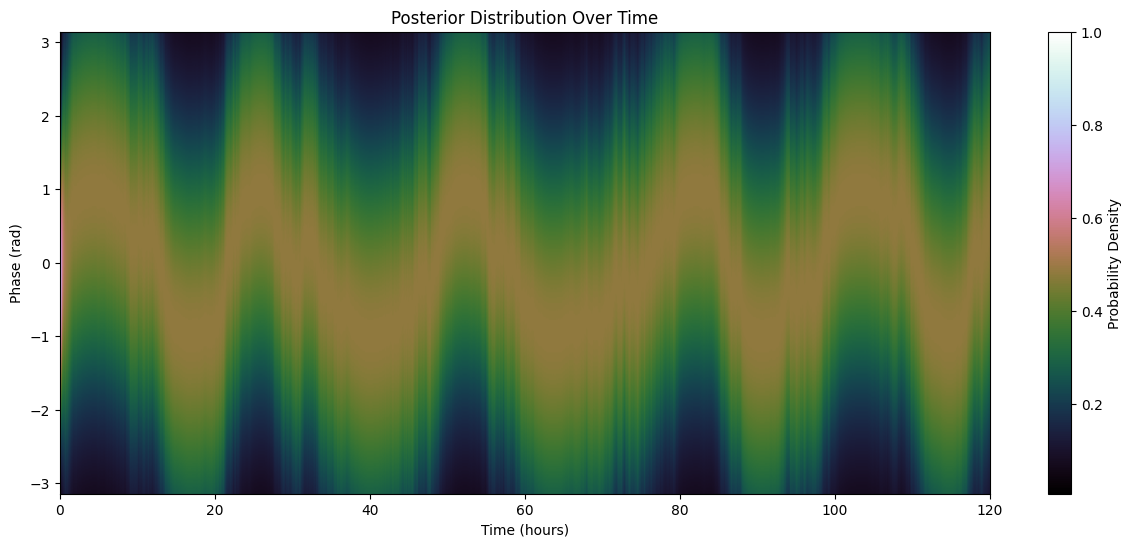

In [149]:
x = np.linspace(-np.pi, np.pi, 300)
pdf_grid = np.zeros((duration, len(x)))

# Fill heatmap
for t in range(duration):
    mu = np.sin(psi2[t])
    sigma = np.sqrt(var_post[t])
    pdf_grid[t, :] = norm.pdf(x, loc=mu, scale=sigma)

# Normalize if you want
pdf_grid /= pdf_grid.max()

# Plot heatmap
plt.figure(figsize=(15, 6))
plt.imshow(pdf_grid.T, aspect='auto', origin='lower',
           extent=[0, T, -np.pi, np.pi], cmap='cubehelix')
plt.xlabel("Time (hours)")
plt.ylabel("Phase (rad)")
plt.title("Posterior Distribution Over Time")
plt.colorbar(label="Probability Density")
plt.show()

### $\text{param sweep}$

#### $\text{1. oscillator distribution   } \mathcal{N}(\mu, \sigma^2)$

mean_period

simulating: 100%|███████████████████████████| 1680/1680 [00:20<00:00, 81.33it/s]


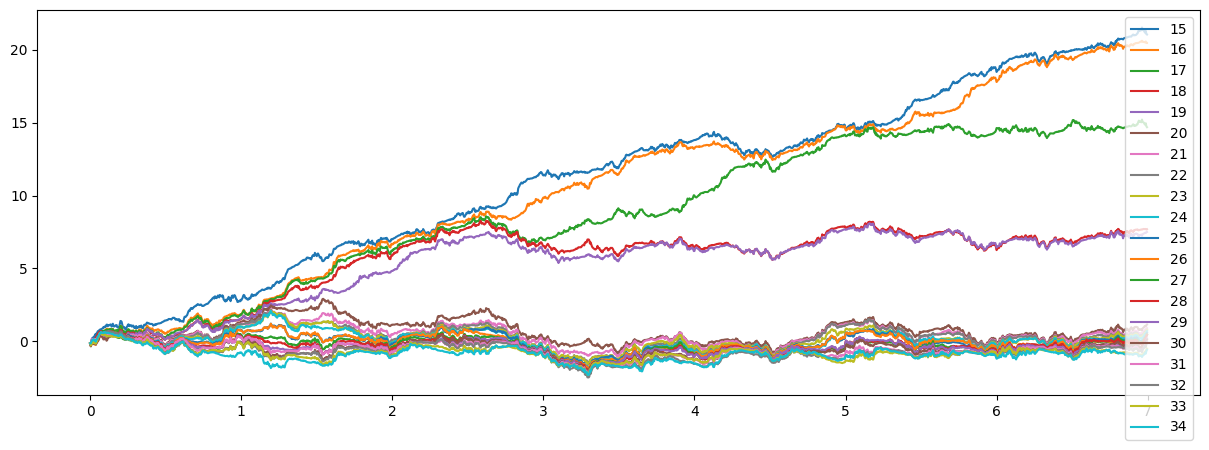

In [53]:
np.random.seed(200)

data=np.load('EKF_EZ_NC.npz')
acc= np.arange(15, 35)

N = 100
T = 24*7 ; dt = 0.1 ; timesteps = np.arange(0, T, dt) ; duration=len(timesteps)

Center = np.zeros((len(acc), duration))
R = np.zeros((len(acc), duration))
PSI = np.zeros((len(acc), duration))

init_cov = 0.1

P_prime=1
P=0
M=7

s,m = sm_simulation(T=T, dt=dt, P=P, M=M)



n=0
plt.figure(figsize=(15,5))
for center in acc:

    mean_period=center
    std_period = 0.2

    var_p = P_prime**2
    var_m = M**2

    var_prior=np.zeros(duration)
    var_post=np.zeros(duration)
    G=np.zeros(duration)



    ################## SCN filter init ###################
    #phase_history = np.zeros((N, duration))

    #g(ω)～N(loc,scale**2) 
    omega = np.random.normal(loc=2 * np.pi / mean_period, scale=(2 * np.pi / mean_period**2)*std_period, size=N)

    K_matrix = np.random.uniform(0, 2, (N, N))
    K_matrix = (K_matrix + K_matrix.T) / 2
    np.fill_diagonal(K_matrix, 0)
    

    kappa_p_prime = 1 / P_prime**2 if P_prime > 0 else 0
    xi = np.random.vonmises(mu=0, kappa=kappa_p_prime, size=(duration, N)) if P_prime > 0 else np.zeros((duration, N)) #xi=np.random.normal(loc=0, scale=P_prime, size=(duration,N))


    for t in tqdm(range(duration), desc="simulating", ncols=80):

        if t==0:
            phases =  data['init_phases']

            var_prev=init_cov 
        else:
            var_prev=var_post[t-1]
        
        #phase_history[:, t]=phases

        order_param = np.mean(np.exp(1j * phases)); '->np.mean(complex number) = np.ang + np.abs'
        R[n,t] = np.abs(order_param)
        PSI[n,t] = np.angle(order_param)


        var_prior[t] = var_prev + var_p
        inv_var_post = 1 / var_prior[t] + 1 / var_m
        var_post[t] = 1 / inv_var_post   

        if t < (duration-1):

            for i in range(N):

                H = np.cos(phases[i]+omega[i])
                gap = m[t]-np.sin(phases[i]+omega[i])
                G = H*var_prior[t]/ (H*var_prior[t]*H + var_m)
   
                coupling_sum = 0
                for j in range(N):
                    coupling_sum += K_matrix[i,j] * np.sin(phases[j] - phases[i])

                phases[i] += (omega[i] + xi[t,i] + G*gap + (1/N)*coupling_sum) * dt

            phases = np.mod(phases+np.pi, 2 * np.pi)-np.pi
    
    plt.plot(timesteps/24, np.unwrap(PSI[n, :])-np.unwrap(s), label=f'{center}')
    
    Center[n, :] = np.unwrap(PSI[n, :])-np.unwrap(s)
    n+=1

plt.legend()
plt.show()

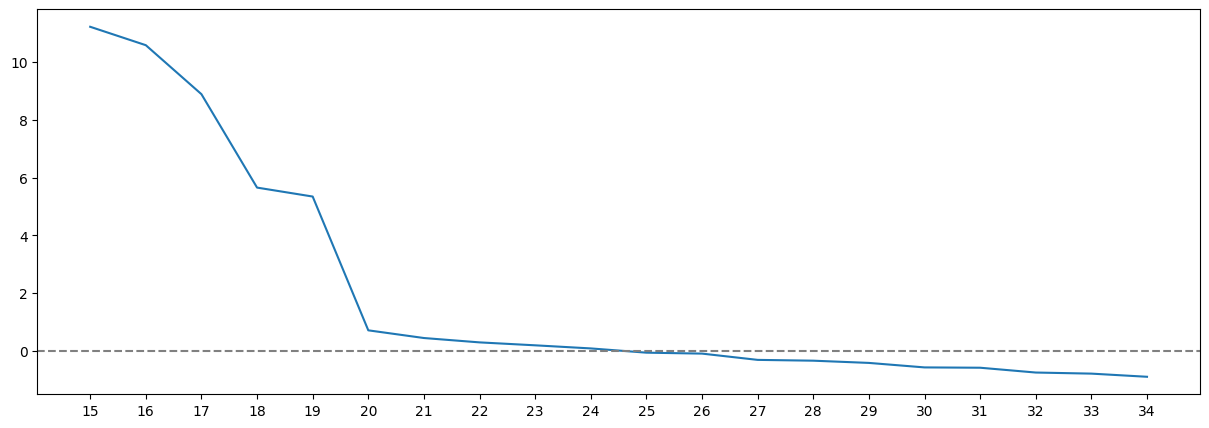

In [56]:
plt.figure(figsize=(15,5))
plt.plot(np.arange(15, 35), np.mean(Center, axis=1))
plt.axhline(y=0, linestyle='--', color='gray')
plt.xticks(np.arange(15, 35));

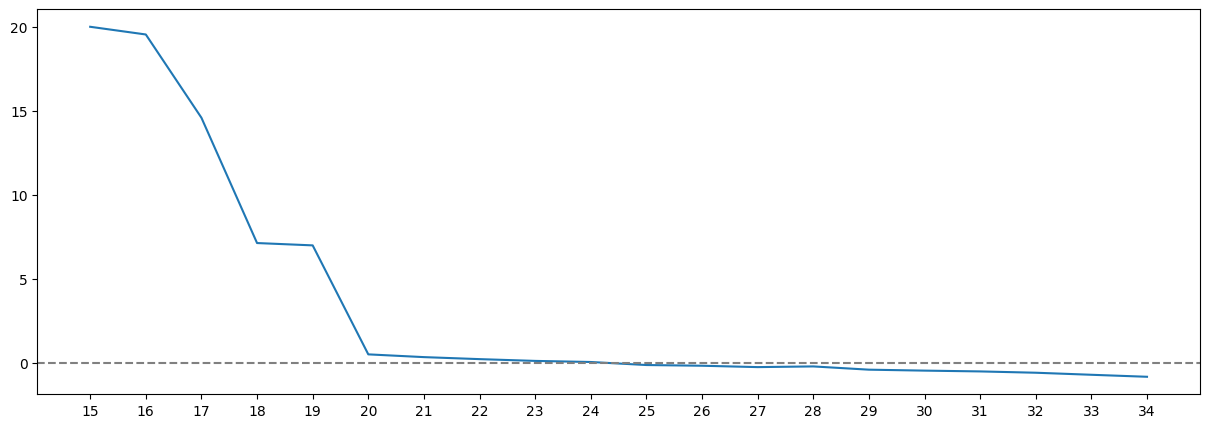

In [57]:
plt.figure(figsize=(15,5))
plt.plot(np.arange(15, 35), np.mean(Center[:,-240:], axis=1))
plt.axhline(y=0, linestyle='--', color='gray')
plt.xticks(np.arange(15, 35));

std_period

simulating48/48: 100%|██████████████████████| 1200/1200 [00:14<00:00, 81.61it/s]


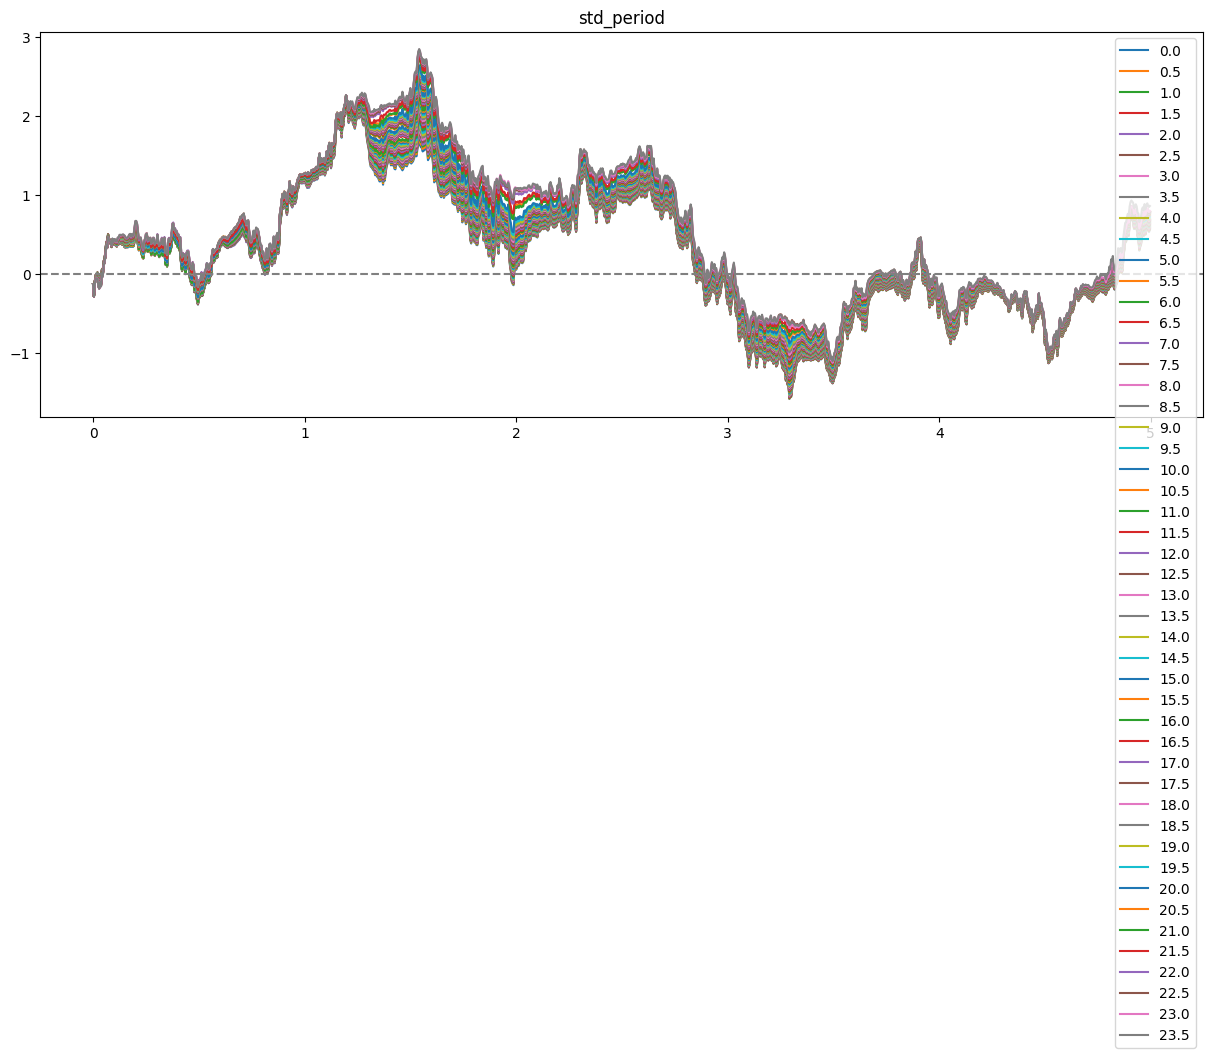

In [33]:
np.random.seed(200)

data=np.load('EKF_EZ_NC.npz')
acc= np.arange(0, 24, 0.5)

N = 100
T = 24*5 ; dt = 0.1 ; timesteps = np.arange(0, T, dt) ; duration=len(timesteps)

SP=np.zeros((len(acc),duration))

n=0
plt.figure(figsize=(15,5))
for sp in acc:

    mean_period=23.5
    std_period = sp



    init_cov = 0.1

    P_prime=1
    P=0
    M=7

    s,m = sm_simulation(T=T, dt=dt, P=P, M=M)

    var_p = P_prime**2
    var_m = M**2

    var_prior=np.zeros(duration)
    var_post=np.zeros(duration)
    G=np.zeros(duration)



    ################## SCN filter init ###################
    phase_history = np.zeros((N, duration))
    psi2 = np.zeros(duration)
    r2  = np.zeros(duration)

    #g(ω)～N(loc,scale**2)
    omega = np.random.normal(loc=2 * np.pi / mean_period, scale=(2 * np.pi / mean_period**2)*std_period, size=N)
    

    K_matrix = np.random.uniform(0, 2, (N, N))
    K_matrix = (K_matrix + K_matrix.T) / 2
    np.fill_diagonal(K_matrix, 0)


    kappa_p_prime = 1 / P_prime**2 if P_prime > 0 else 0
    xi = data['xi']


    for t in tqdm(range(duration), desc=f"simulating{n+1}/{len(acc)}", ncols=80):

        if t==0:
            phases =  data['init_phases']

            var_prev=init_cov 
        else:
            var_prev=var_post[t-1]
        
        phase_history[:, t]=phases

        order_param = np.mean(np.exp(1j * phases)); '->np.mean(complex number) = np.ang + np.abs'
        r2[t] = np.abs(order_param)
        psi2[t] = np.angle(order_param)


        var_prior[t] = var_prev + var_p
        inv_var_post = 1 / var_prior[t] + 1 / var_m
        var_post[t] = 1 / inv_var_post   

        if t < (duration-1):

            for i in range(N):

                H = np.cos(phases[i]+omega[i])
                gap = m[t]-np.sin(phases[i]+omega[i])
                G = H*var_prior[t]/ (H*var_prior[t]*H + var_m)
   
                coupling_sum = 0
                for j in range(N):
                    coupling_sum += K_matrix[i,j] * np.sin(phases[j] - phases[i])

                phases[i] += (omega[i] + xi[t,i] + G*gap + (1/N)*coupling_sum) * dt

            phases = np.mod(phases+np.pi, 2 * np.pi)-np.pi
    
    plt.plot(timesteps/24, np.unwrap(psi2)-np.unwrap(s), label=f'{sp}')

    SP[n, :] = np.unwrap(psi2)-np.unwrap(s)
    n+=1

plt.title('std_period')
plt.axhline(y=0, linestyle='--', color='gray')
plt.legend()
plt.show()

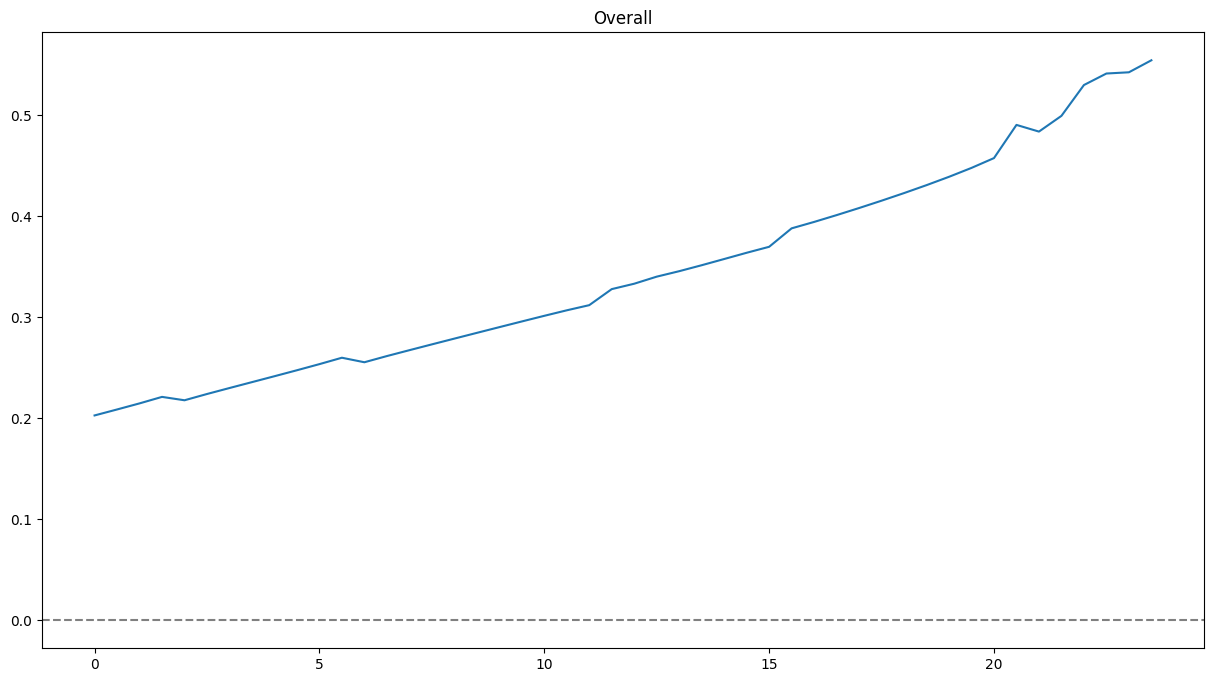

In [35]:
plt.figure(figsize=(15,8))
plt.plot(acc, np.mean(SP[:], axis=1))
plt.axhline(y=0, linestyle='--', color='gray')
plt.title('Overall');

1-3. Mean_period X std_period 

In [61]:
np.random.seed(200)

data=np.load('EKF_EZ_NC.npz')

c_acc = np.arange(15, 35)
sp_acc = np.arange(0, 24, 2)

N = 100
T = 24*10 ; dt = 0.1 ; timesteps = np.arange(0, T, dt) ; duration=len(timesteps)

AD = np.zeros((len(c_acc), len(sp_acc), duration))
R = np.zeros((len(c_acc), len(sp_acc), duration))
PSI = np.zeros((len(c_acc), len(sp_acc), duration))

init_cov = 0.1

P_prime=1
P=0
M=7

s,m = sm_simulation(T=T, dt=dt, P=P, M=M)


kappa_p_prime = 1 / P_prime**2 if P_prime > 0 else 0
xi = np.random.vonmises(mu=0, kappa=kappa_p_prime, size=(duration, N)) if P_prime > 0 else np.zeros((duration, N)) #xi=np.random.normal(loc=0, scale=P_prime, size=(duration,N))

K_matrix = np.random.uniform(0, 2, (N, N))
K_matrix = (K_matrix + K_matrix.T) / 2
np.fill_diagonal(K_matrix, 0)


n1=0
for center in c_acc:
    n2=0
    for sp in sp_acc:

        mean_period=center
        std_period = sp

        var_p = P_prime**2
        var_m = M**2

        var_prior=np.zeros(duration)
        var_post=np.zeros(duration)
        G=np.zeros(duration)



        ################## SCN filter init ###################
        #phase_history = np.zeros((N, duration))

        #g(ω)～N(loc,scale**2) 
        omega = np.abs(np.random.normal(loc=2 * np.pi / mean_period, scale=(2 * np.pi / mean_period**2)*std_period, size=N))


        for t in tqdm(range(duration), desc=f'{n1*len(sp_acc)+n2}/{len(c_acc)*len(sp_acc)}', ncols=80):

            if t==0:
                phases =  data['init_phases']

                var_prev=init_cov 
            else:
                var_prev=var_post[t-1]
            
            #phase_history[:, t]=phases

            order_param = np.mean(np.exp(1j * phases)); '->np.mean(complex number) = np.ang + np.abs'
            R[n1, n2, t] = np.abs(order_param)
            PSI[n1, n2, t] = np.angle(order_param)


            var_prior[t] = var_prev + var_p
            inv_var_post = 1 / var_prior[t] + 1 / var_m
            var_post[t] = 1 / inv_var_post   

            if t < (duration-1):

                for i in range(N):

                    H = np.cos(phases[i]+omega[i])
                    gap = m[t]-np.sin(phases[i]+omega[i])
                    G = H*var_prior[t]/ (H*var_prior[t]*H + var_m)
    
                    coupling_sum = 0
                    for j in range(N):
                        coupling_sum += K_matrix[i,j] * np.sin(phases[j] - phases[i])

                    phases[i] += (omega[i] + xi[t,i] + G*gap + (1/N)*coupling_sum) * dt

                phases = np.mod(phases+np.pi, 2 * np.pi)-np.pi
        
        AD[n1, n2, :] = np.unwrap(PSI[n1, n2, :])-np.unwrap(s)
        n2+=1
    n1+=1

239/240: 100%|██████████████████████████████| 2400/2400 [00:29<00:00, 82.24it/s]


In [143]:
np.savez('EKF_EZ_Param_meanXstd.npz', PSI=PSI, R=R, AD=AD, K_matrix=K_matrix)

In [28]:
big_data=np.load('EKF_EZ_Param_meanXstd.npz')
PSI=big_data['PSI']
R=big_data['R']
AD=big_data['AD']
c_acc = np.arange(15, 35)
sp_acc = np.arange(0, 24, 2)
AD_wrapped = (AD + np.pi) % (2 * np.pi) - np.pi

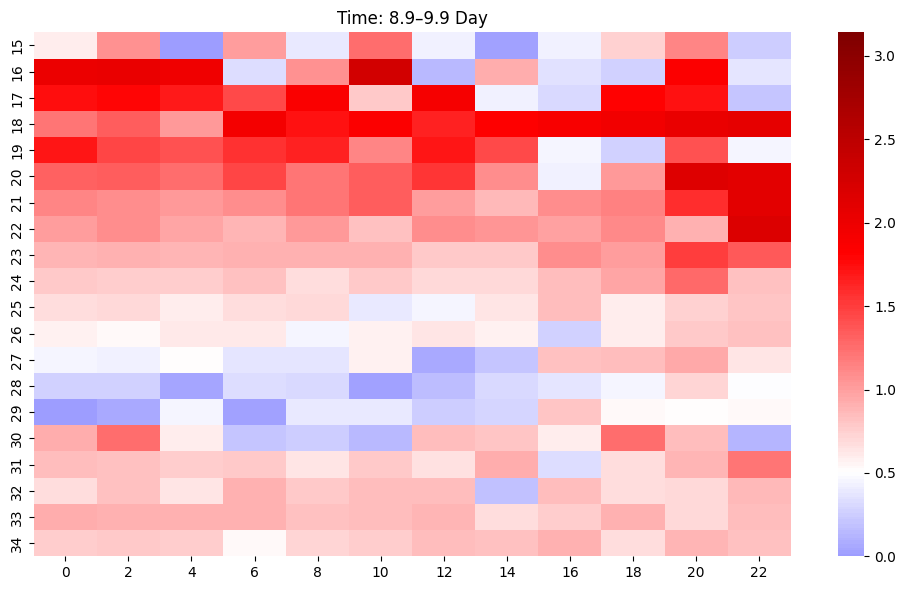

In [29]:
from IPython.display import clear_output
W = 240

for t in range(0, AD.shape[2] - W, 20):
    alignment_error = np.mean(AD_wrapped[:, :, t:t+W], axis=2)

    plt.figure(figsize=(10, 6))
    sns.heatmap(
        np.abs(alignment_error),
        xticklabels=sp_acc,
        yticklabels=c_acc,
        cmap='seismic',
        center=0.5,
        vmin=0,
        vmax=np.pi,
        annot=False,
        cbar=True
    )
    plt.title(f"Time: {t*dt/24 :.1f}–{(t+W)*dt/24 :.1f} Day")
    plt.tight_layout()

    clear_output(wait=True)
    plt.show()
    plt.pause(0.25)


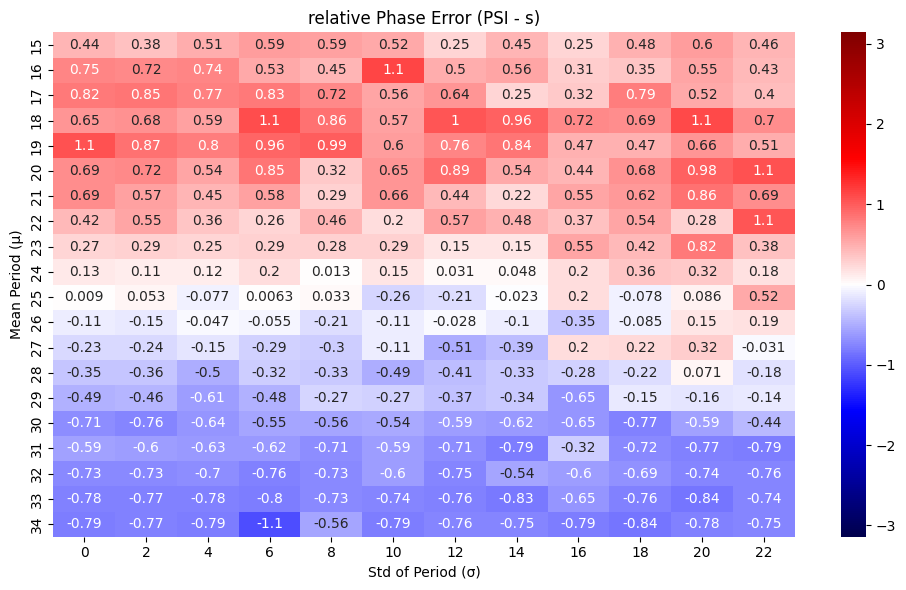

In [114]:
AD_wrapped = (AD + np.pi) % (2 * np.pi) - np.pi
# Compute mean or final phase error over time
alignment_error = np.mean(AD_wrapped[:, :, 480:], axis=2) # shape: (len(c_acc), len(sp_acc))

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(alignment_error, xticklabels=sp_acc, yticklabels=c_acc, cmap='seismic', center=0, annot=True, vmin=-np.pi, vmax=np.pi)

plt.title("relative Phase Error (PSI - s)")
plt.xlabel("Std of Period (σ)")
plt.ylabel("Mean Period (μ)")
plt.tight_layout()
plt.show()

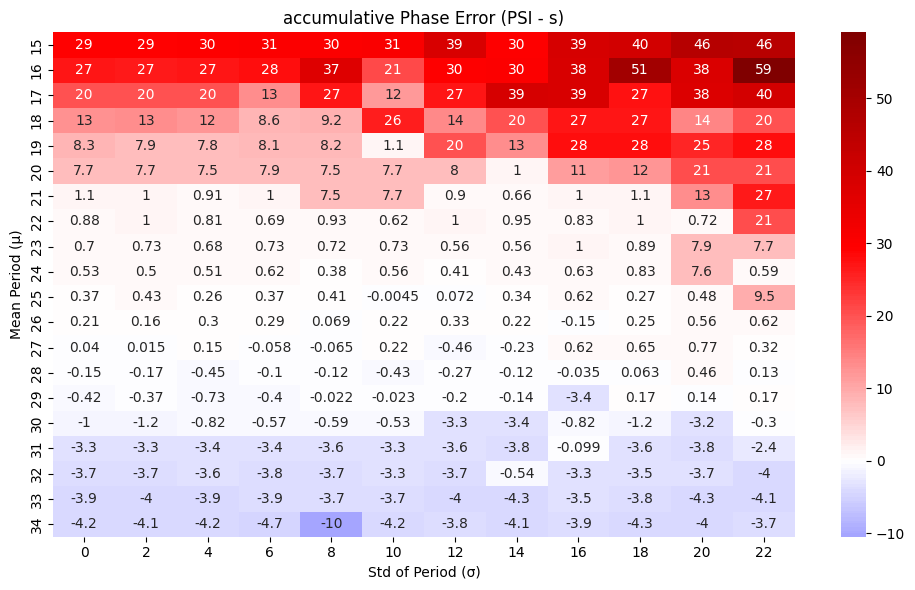

In [5]:
# Compute mean or final phase error over time
alignment_error = np.mean(AD[:, :, -480:], axis=2) # shape: (len(c_acc), len(sp_acc))

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(alignment_error, xticklabels=sp_acc, yticklabels=c_acc, cmap='seismic', center=0, annot=True)

plt.title("accumulative Phase Error (PSI - s)")
plt.xlabel("Std of Period (σ)")
plt.ylabel("Mean Period (μ)")
plt.tight_layout()
plt.show()

In [ ]:
# Compute mean or final phase error over time
alignment_error = np.mean(AD[:, :, -480:], axis=2) # shape: (len(c_acc), len(sp_acc))

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(alignment_error, xticklabels=sp_acc, yticklabels=c_acc, cmap='seismic', center=0, annot=True)

plt.title("accumulative Phase Error (PSI - s)")
plt.xlabel("Std of Period (σ)")
plt.ylabel("Mean Period (μ)")
plt.tight_layout()
plt.show()

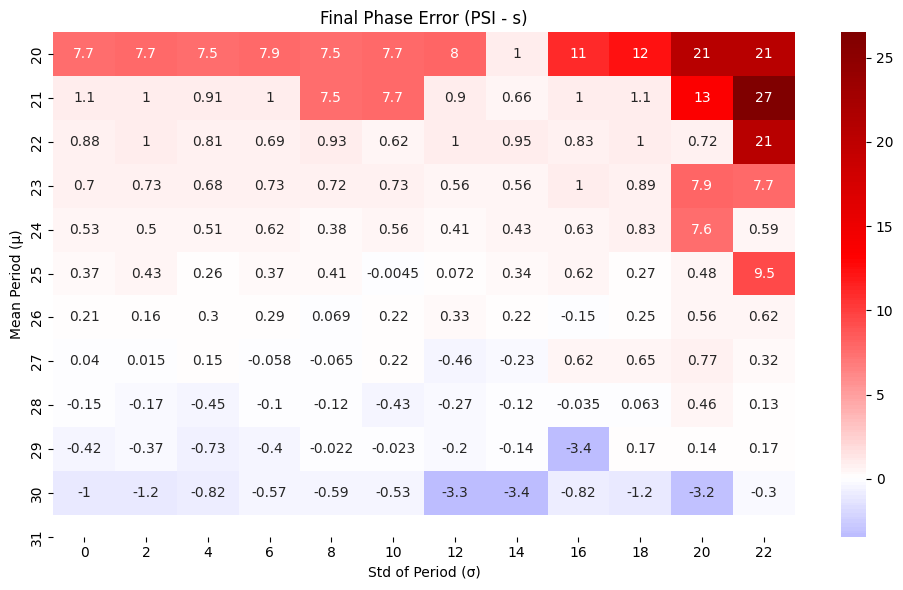

In [6]:
alignment_error = np.mean(AD[5:16, :, -480:], axis=2) # shape: (len(c_acc), len(sp_acc))

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(alignment_error, xticklabels=sp_acc, yticklabels=range(20,32), cmap='seismic', center=0, annot=True)

plt.title("Final Phase Error (PSI - s)")
plt.xlabel("Std of Period (σ)")
plt.ylabel("Mean Period (μ)")
plt.tight_layout()
plt.show()

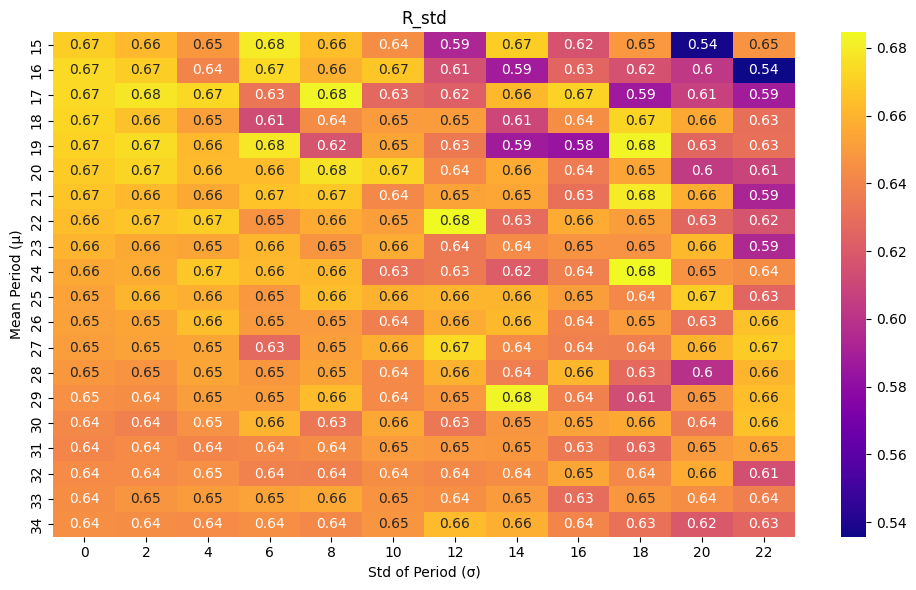

In [43]:
plt.figure(figsize=(10, 6))
sns.heatmap(np.mean(R[:,:, :60], axis=2), xticklabels=sp_acc, yticklabels=c_acc, cmap='plasma', annot=True)

plt.title("R_std")
plt.xlabel("Std of Period (σ)")
plt.ylabel("Mean Period (μ)")
plt.tight_layout()
plt.show()

K_matrix

In [145]:
np.random.seed(200)

data=np.load('EKF_EZ_NC.npz')

acc = np.arange(0.5, 15.5, 0.5)

N = 100
T = 24*10 ; dt = 0.1 ; timesteps = np.arange(0, T, dt) ; duration=len(timesteps)

mean_period=23.5
std_period = 0.2





init_cov = 0.1

P_prime=1
P=0
M=7

s,m = sm_simulation(T=T, dt=dt, P=P, M=M)

var_p = P_prime**2
var_m = M**2

Phase_His = np.zeros((len(acc), N, duration))
PSI = np.zeros((len(acc),duration))
R  = np.zeros((len(acc),duration))
K_matrix=np.zeros((len(acc), N, N))

n=0
for k_mean in acc:
    var_prior=np.zeros(duration)
    var_post=np.zeros(duration)
    G=np.zeros(duration)



    ################## SCN filter init ##################

    #g(ω)～N(loc,scale**2)
    omega = np.abs(np.random.normal(loc=2 * np.pi / mean_period, scale=(2 * np.pi / mean_period**2)*std_period, size=N))



    K_matrix[n] = np.random.normal(loc = k_mean, scale= 0.1, size=(N, N))
    K_matrix[n] = (K_matrix[n] + K_matrix[n].T) / 2
    np.fill_diagonal(K_matrix[n], 0)

    kappa_p_prime = 1 / P_prime**2 if P_prime > 0 else 0
    xi = np.random.vonmises(mu=0, kappa=kappa_p_prime, size=(duration, N)) if P_prime > 0 else np.zeros((duration, N)) #xi=np.random.normal(loc=0, scale=P_prime, size=(duration,N))


    for t in tqdm(range(duration), desc=f"simulating{n+1}/{len(acc)}", ncols=80):

        if t==0:
            phases =  data['init_phases']

            var_prev=init_cov 
        else:
            var_prev=var_post[t-1]
        
        Phase_His[n, :, t]=phases

        order_param = np.mean(np.exp(1j * phases)); '->np.mean(complex number) = np.ang + np.abs'
        R[n, t] = np.abs(order_param)
        PSI[n, t] = np.angle(order_param)


        var_prior[t] = var_prev + var_p
        inv_var_post = 1 / var_prior[t] + 1 / var_m
        var_post[t] = 1 / inv_var_post   

        if t < (duration-1):

            for i in range(N):

                H = np.cos(phases[i]+omega[i])
                gap = m[t]-np.sin(phases[i]+omega[i])
                G = H*var_prior[t]/ (H*var_prior[t]*H + var_m)
                
                coupling_sum = 0
                for j in range(N):
                    coupling_sum += K_matrix[n,i,j] * np.sin(phases[j] - phases[i])

                phases[i] += (omega[i] + xi[t,i] + G*gap + (1/N)*coupling_sum) * dt
        
            phases = np.mod(phases+np.pi, 2 * np.pi)-np.pi
    
    n+=1


simulating30/30: 100%|██████████████████████| 2400/2400 [00:31<00:00, 77.12it/s]


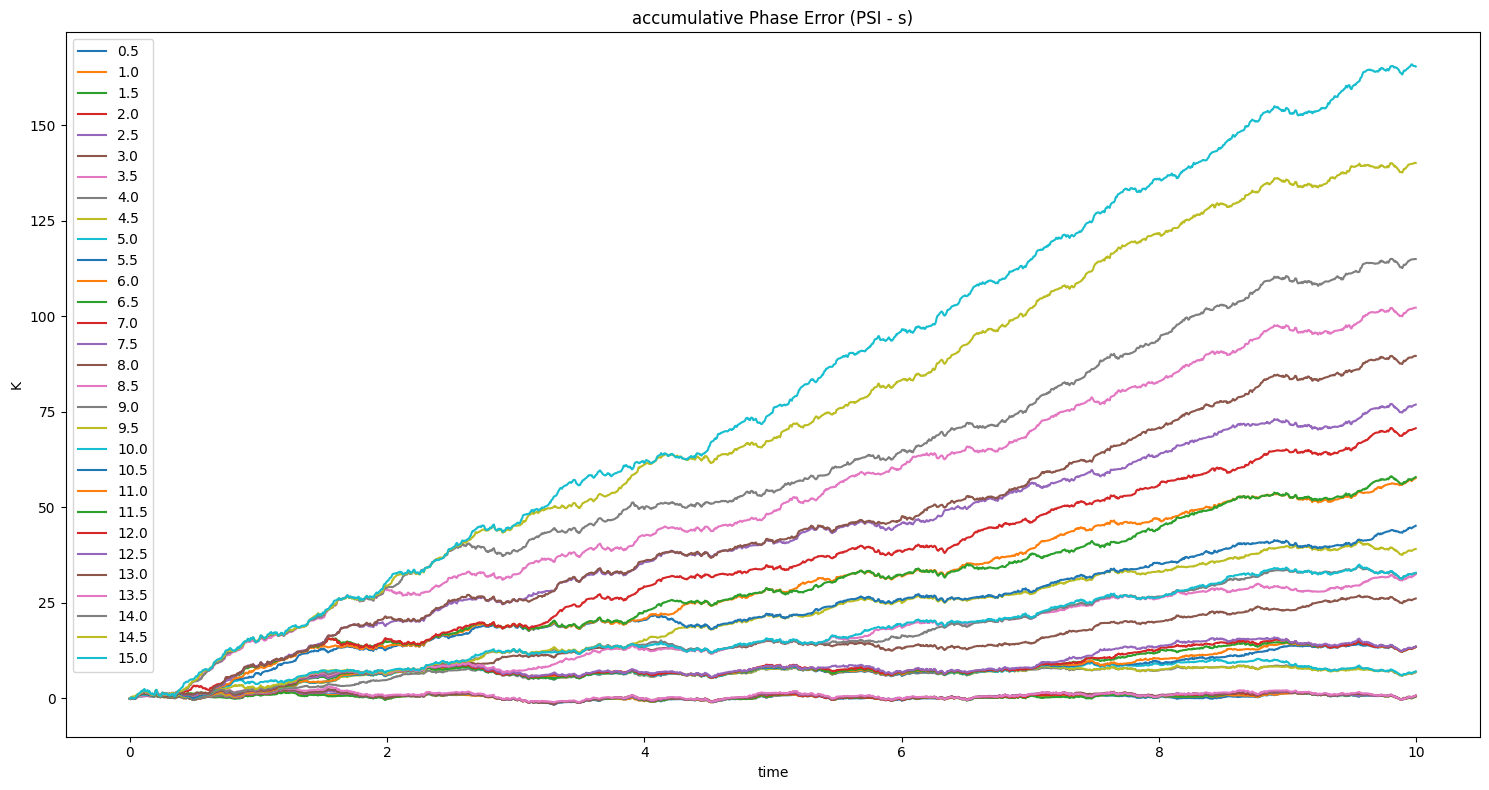

In [153]:
angular_diff=np.zeros((30, duration))

plt.figure(figsize=(15, 8))
for n in range(30):
    angular_diff[n] = np.unwrap(PSI[n])-np.unwrap(s)
    plt.plot(timesteps/24, np.unwrap(PSI[n])-np.unwrap(s), label=f'{0.5+n*0.5}')

plt.title("accumulative Phase Error (PSI - s)")
plt.xlabel("time")
plt.ylabel("K")
plt.legend()
plt.tight_layout()
plt.show()

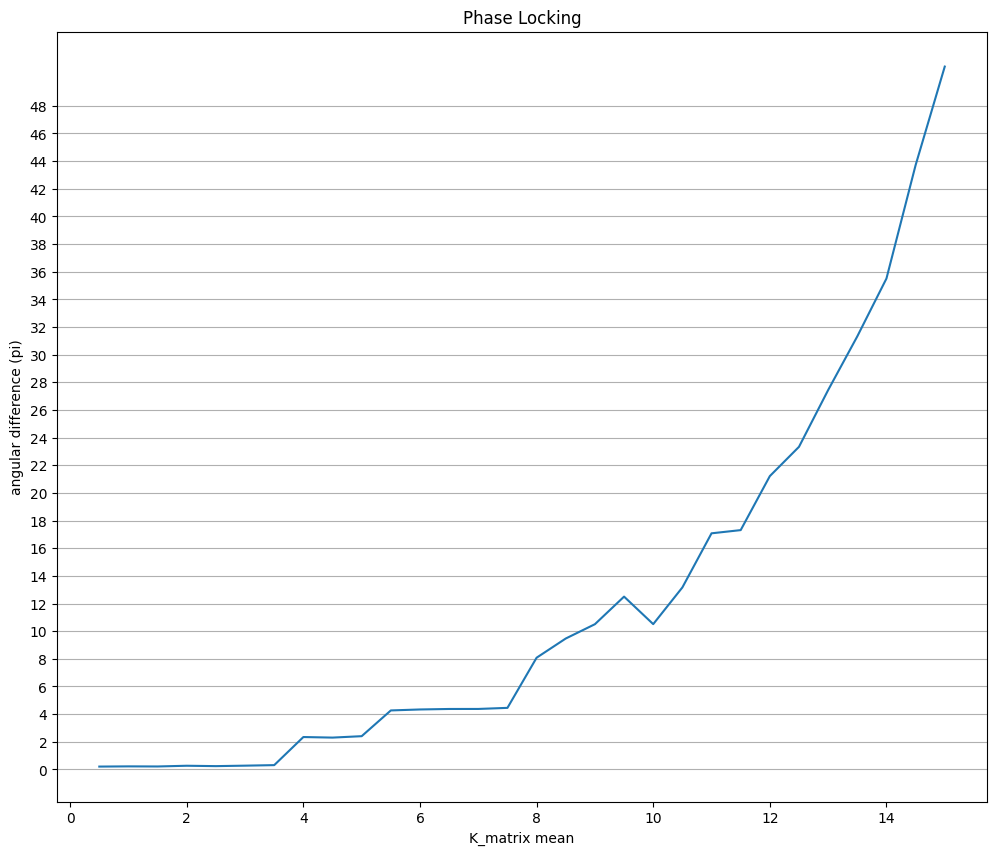

In [161]:
plt.figure(figsize=(12, 10))
plt.plot(acc, np.mean(angular_diff[:, -240:]/(np.pi), axis=1))
plt.grid(axis='y')
plt.yticks(range(0, 50, 2))
plt.xlabel('K_matrix mean')
plt.ylabel('angular difference (pi)')
plt.title('Phase Locking')
plt.show();

In [135]:
K_matrix.shape

(20, 100, 100)

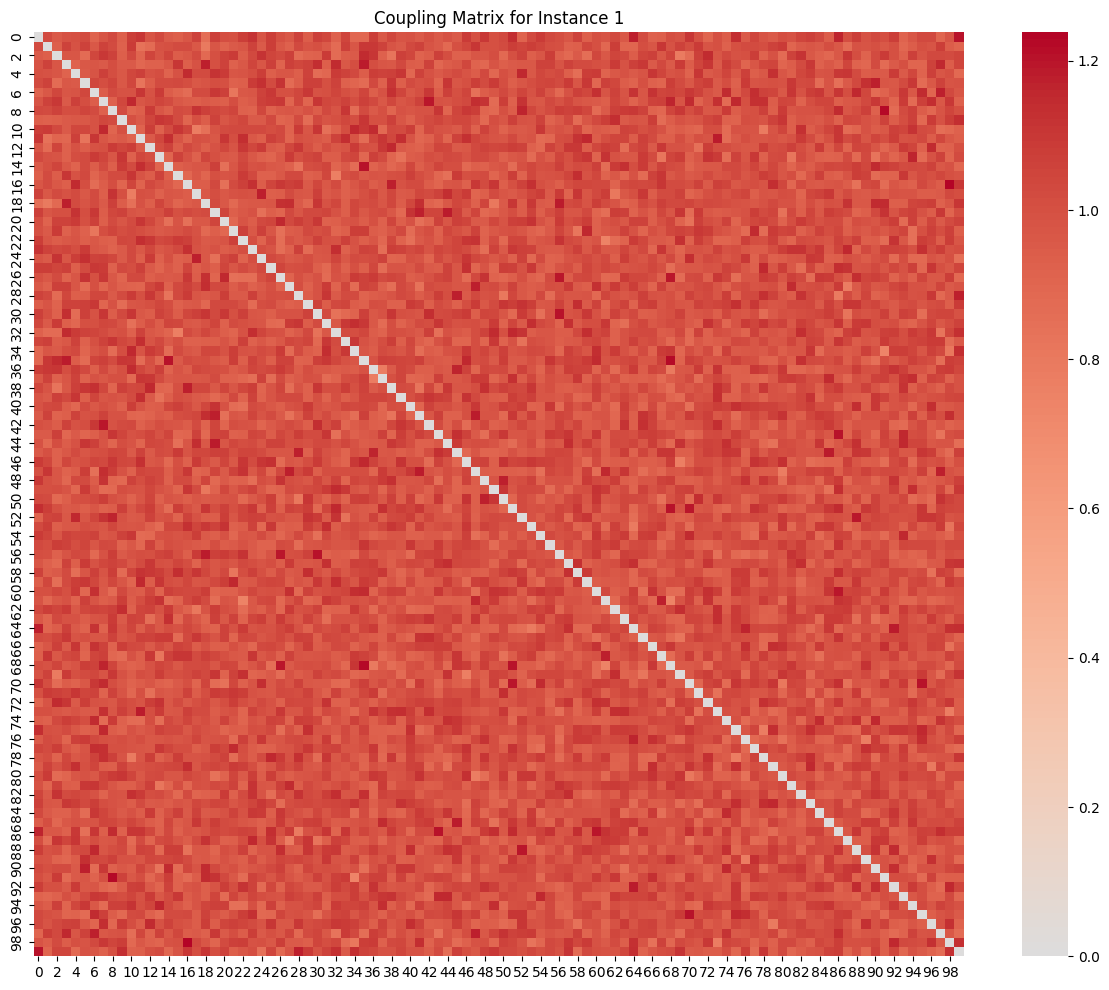

In [142]:
plt.figure(figsize=(15, 12))
sns.heatmap(K_matrix[1], cmap='coolwarm', center=0)
plt.title("Coupling Matrix for Instance 1")
plt.show();

measurement_noise

In [75]:
np.random.seed(200)

acc3=np.arange(2, 42, 2)


data=np.load('EKF_EZ_NC.npz')
N = 100
T = 24*10 ; dt = 0.1 ; timesteps = np.arange(0, T, dt) ; duration=len(timesteps)
MN = np.zeros((len(acc3), duration))

K_matrix = np.random.uniform(0, 0.2, (N, N))
K_matrix = (K_matrix + K_matrix.T) / 2
np.fill_diagonal(K_matrix, 0)

P_prime=0.5

kappa_p_prime = 1 / P_prime**2 if P_prime > 0 else 0
xi = np.random.vonmises(mu=0, kappa=kappa_p_prime, size=(duration, N)) if P_prime > 0 else np.zeros((duration, N)) #xi=np.random.normal(loc=0, scale=P_prime, size=(duration,N))

phase_history = np.zeros((len(acc3), N, duration))
gap=np.zeros((len(acc3),N, duration))
G=np.zeros((len(acc3),N, duration))

n=0
for mn in acc3:
    mean_period=23.5
    std_period = 0.2




    init_cov = 0.1

    P=0
    M=mn

    s,m = sm_simulation(T=T, dt=dt, P=P, M=M)

    var_p = P_prime**2
    var_m = M**2

    var_prior=np.zeros(duration)
    var_post=np.zeros(duration)



    ################## SCN filter init ###################
    psi = np.zeros(duration)
    r  = np.zeros(duration)


    # von Mises sample
    omega = data['omega']



    for t in tqdm(range(duration), desc=f"simulating{n+1}/{len(acc3)}", ncols=80):

        if t==0:
            phases =  data['init_phases']

            var_prev=init_cov 
        else:
            var_prev=var_post[t-1]
        
        phase_history[n, :, t]=phases

        order_param = np.mean(np.exp(1j * phases)); '->np.mean(complex number) = np.ang + np.abs'
        r[t] = np.abs(order_param)
        psi[t] = np.angle(order_param)


        var_prior[t] = var_prev + var_p
        inv_var_post = 1 / var_prior[t] + 1 / var_m
        var_post[t] = 1 / inv_var_post   

        if t < (duration-1):

            for i in range(N):

                H = np.cos(phases[i]+omega[i])
                gap[n,i,t] = m[t]-np.sin(phases[i]+omega[i])
                G[n,i,t] = H*var_prior[t]/ (H*var_prior[t]*H + var_m)

                coupling_sum = 0
                for j in range(N):
                    coupling_sum += K_matrix[i,j] * np.sin(phases[j] - phases[i])

                phases[i] += (omega[i] + xi[t,i] + G[n,i,t]*gap[n,i,t] + (1/N)*coupling_sum) * dt
        
            phases = np.mod(phases+np.pi, 2 * np.pi)-np.pi

    MN[n, :]=(np.unwrap(psi)-np.unwrap(s))
    n+=1

simulating20/20: 100%|██████████████████████| 2400/2400 [00:30<00:00, 78.61it/s]


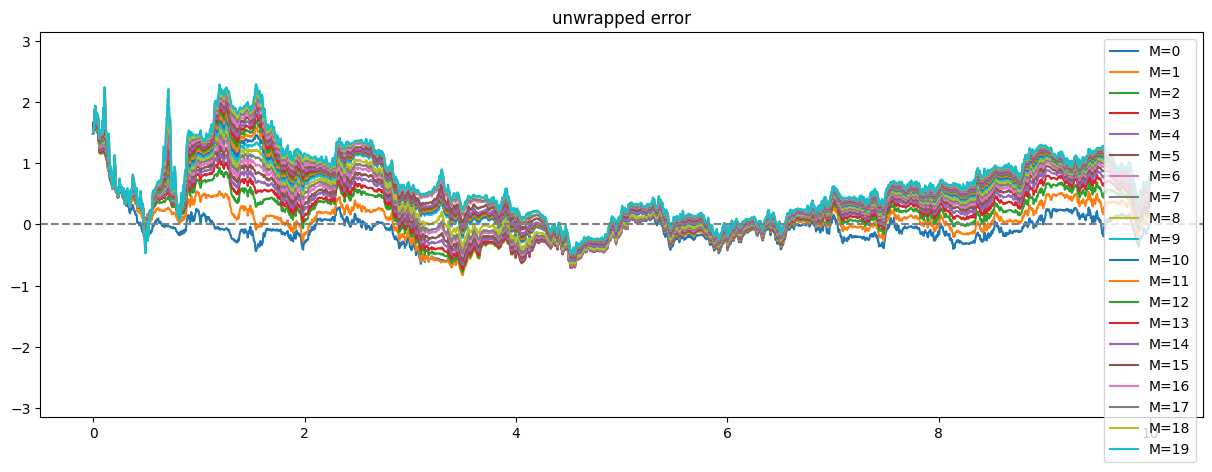

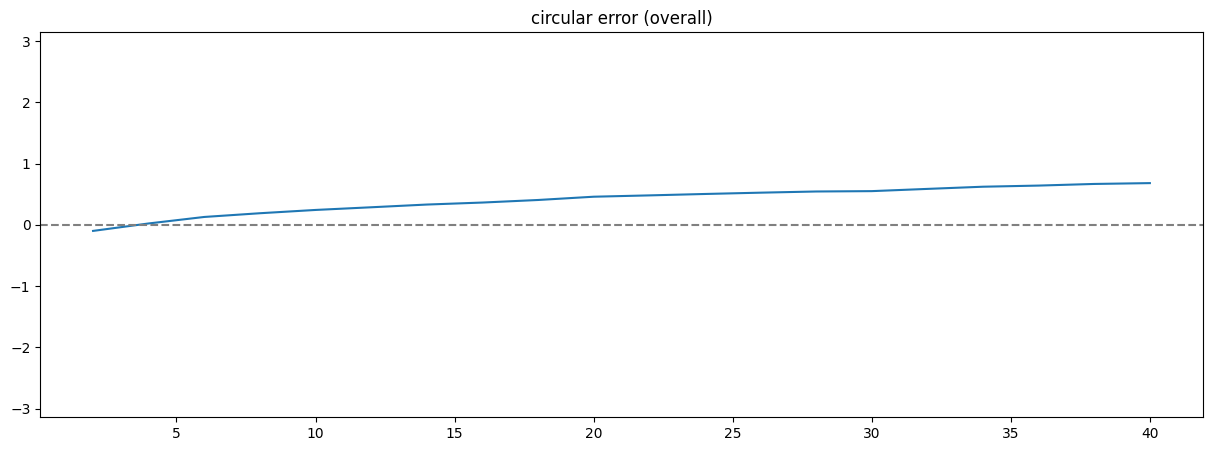

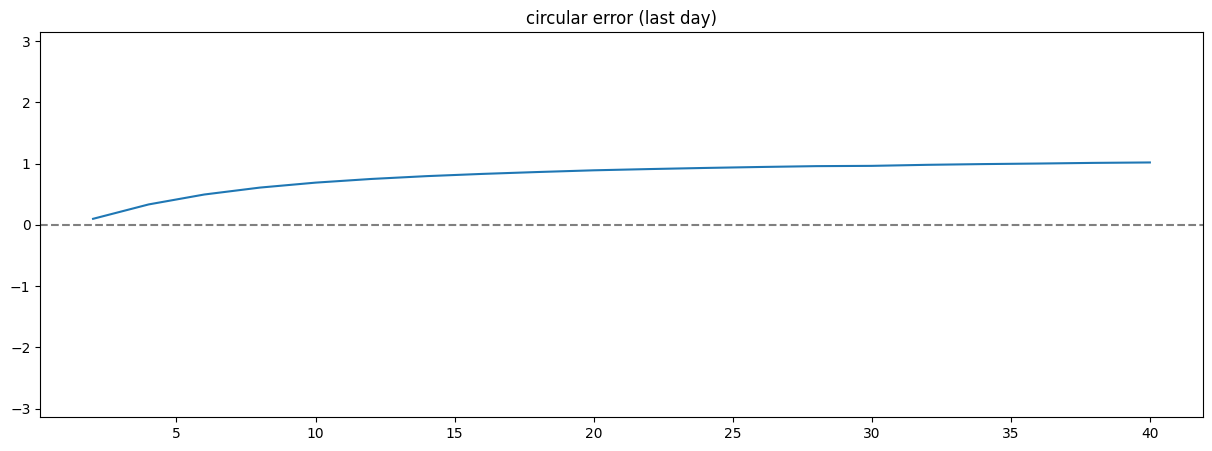

In [77]:
plt.figure(figsize=(15,5))
for i in range(20):
    plt.plot(timesteps/24, MN[i], label=f'M={i}')
plt.axhline(y=0, linestyle='--', color='gray')
plt.legend()
plt.title('unwrapped error')
plt.ylim(-np.pi, np.pi)
plt.show()

plt.figure(figsize=(15,5))
plt.plot(acc3, np.mean(MN, axis=1))
plt.title('circular error (overall)')
plt.ylim(-np.pi, np.pi)
plt.axhline(y=0, linestyle='--', color='gray')
plt.show()

plt.figure(figsize=(15,5))
plt.title('circular error (last day)')
plt.plot(acc3, np.mean(MN[:,-240:], axis=1))
plt.ylim(-np.pi, np.pi)
plt.axhline(y=0, linestyle='--', color='gray')
plt.show();

In [79]:
print(phase_history.shape)

(20, 100, 2400)


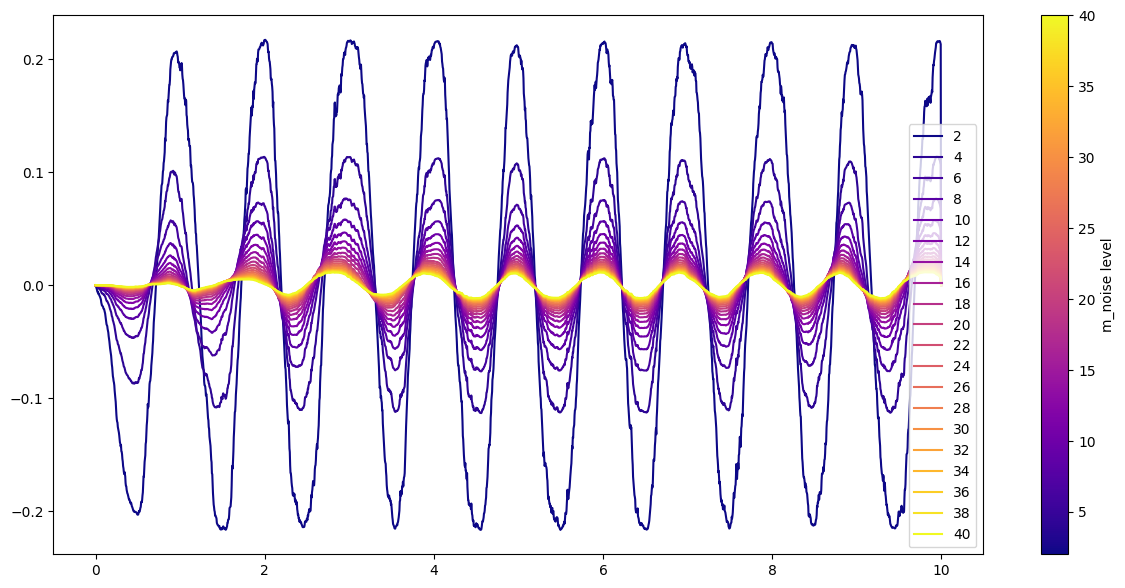

In [ ]:
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap

plt.figure(figsize=(15,7))

cmap = plt.colormaps['plasma']
norm = Normalize(vmin=min(acc3), vmax=max(acc3))

for index in range(len(acc3)):
    color = cmap(norm(acc3[index]))
    plt.plot(timesteps/24, np.mean(G[index, :, :], axis=0), color=color, label=f'{acc3[index]}')

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

plt.colorbar(sm, ax=plt.gca(),  label='m_noise level')

plt.legend()
plt.show();

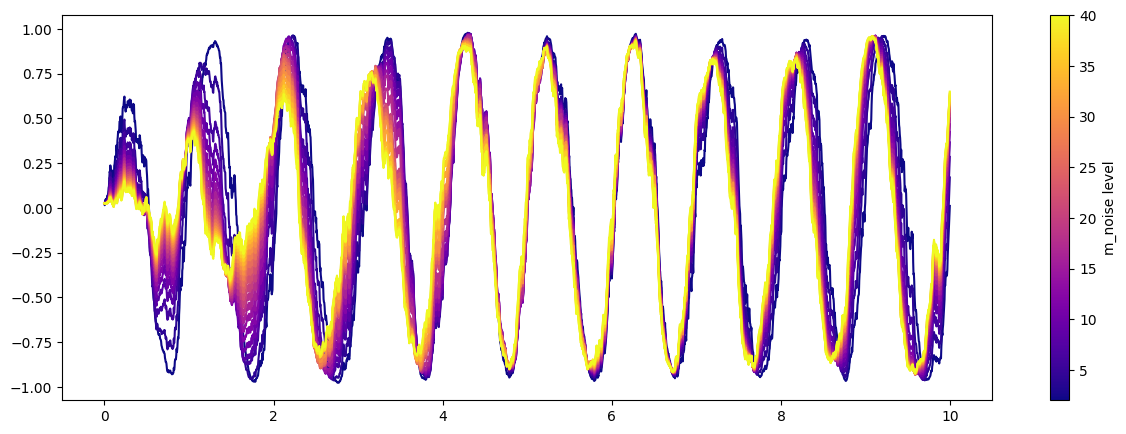

(100, 2400)


In [ ]:
cmap = plt.colormaps['plasma']
norm = Normalize(vmin=min(acc3), vmax=max(acc3))

plt.figure(figsize=(15,5))

for index in range(len(acc3)):
    color = cmap(norm(acc3[index]))
    plt.plot(timesteps/24, np.mean(np.sin(phase_history[index,:,:]), axis=0), color=color) # m_hat = m-gap

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

plt.colorbar(sm, ax=plt.gca(),  label='m_noise level')
plt.show()

In [ ]:
print("Max m_hat:", np.max(m - gap[index, :, :]))
print("Min m_hat:", np.min(m - gap[index, :, :]))ㄋㄌ
print("Expected theoretical bound:", -1, "to", 1)


Max m_hat: 0.9999999996478337
Min m_hat: -55.18296249239617
Expected theoretical bound: -1 to 1


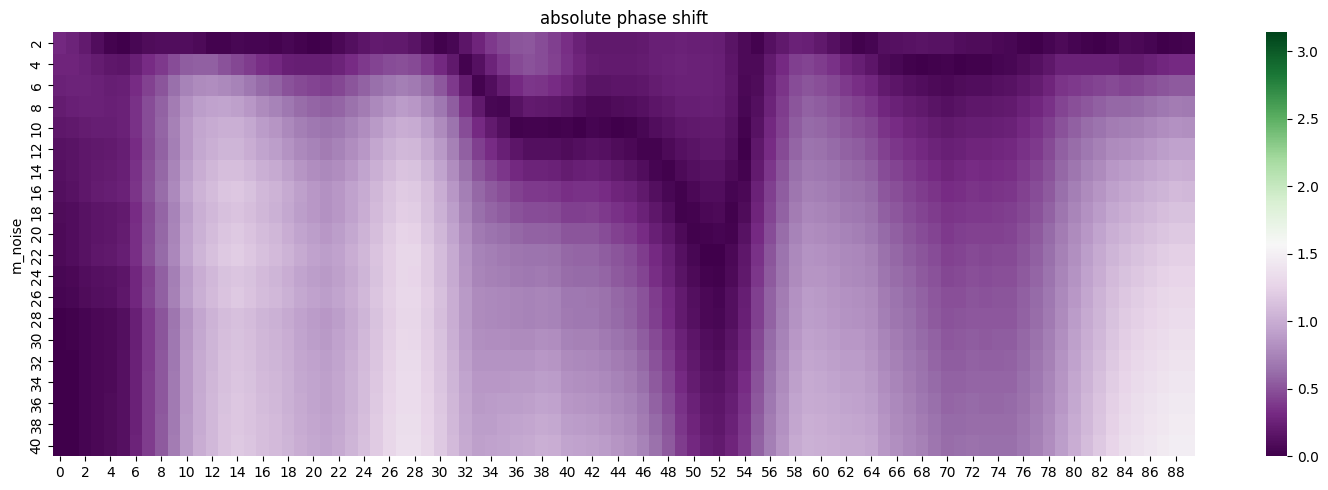

In [88]:
from IPython.display import clear_output

MN_wrapped=(MN + np.pi) % (2 * np.pi) - np.pi
W = 120

alignment_error=np.zeros((len(MN_wrapped), len(range(0, MN.shape[1] - W, 20))))

for i, t in enumerate(range(0, MN.shape[1] - W, 20)):
    alignment_error[:,i] = np.abs(np.mean(MN_wrapped[ :, t:t+W], axis=1))
    


plt.figure(figsize=(15, 5))
sns.heatmap(
    alignment_error,
    yticklabels=acc3,
    cmap='PRGn',
    #center=0,
    vmin=0,
    vmax=np.pi,
    cbar=True
)
plt.ylabel("m_noise")
plt.title(f"absolute phase shift")
plt.tight_layout()

plt.show()

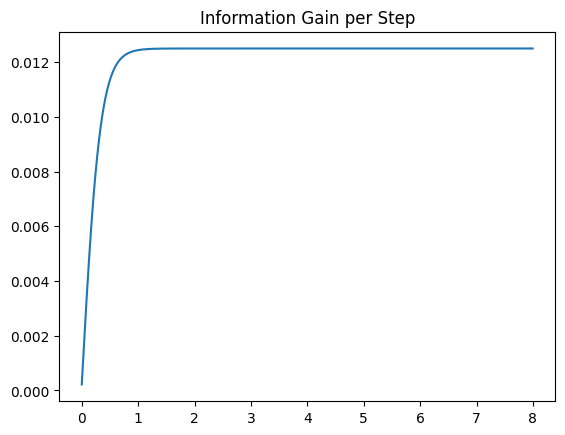

In [60]:
info_gain = np.log(var_prior/var_post)
plt.plot(timesteps / 24, info_gain)
plt.title("Information Gain per Step");

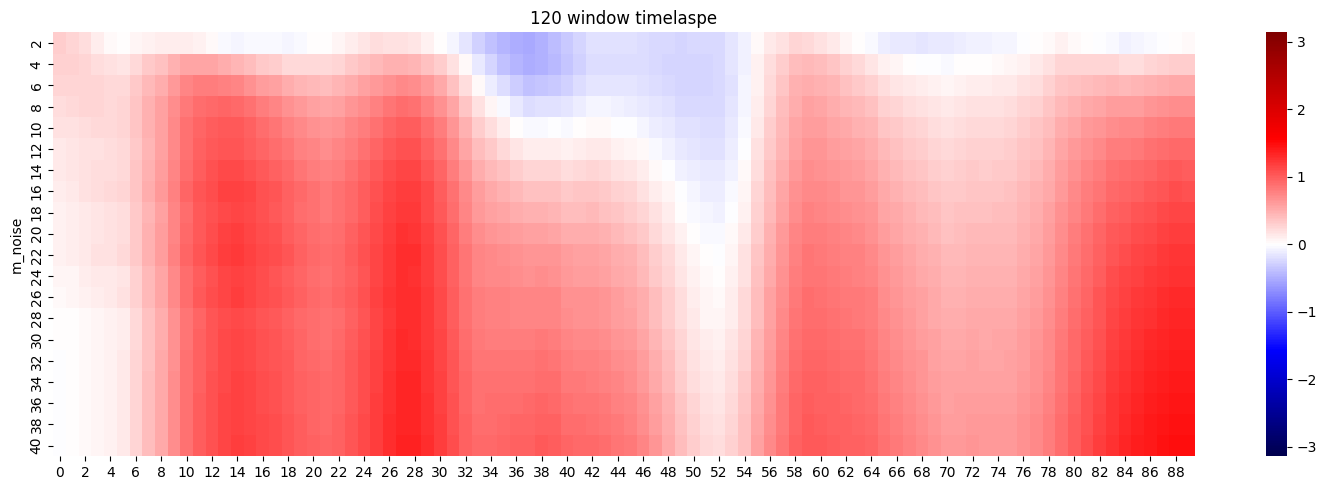

In [70]:
from IPython.display import clear_output

MN_wrapped=(MN + np.pi) % (2 * np.pi) - np.pi
W = 120

alignment_error=np.zeros((len(MN_wrapped), len(range(0, MN.shape[1] - W, 20))))

for i, t in enumerate(range(0, MN.shape[1] - W, 20)):
    alignment_error[:,i] = np.mean(MN_wrapped[ :, t:t+W], axis=1)
    


plt.figure(figsize=(15, 5))
sns.heatmap(
    alignment_error,
    yticklabels=acc3,
    cmap='seismic',
    center=0,
    vmin=-np.pi,
    vmax=np.pi,
    cbar=True
)
plt.ylabel("m_noise")
plt.title(f"{W} window timelaspe")
plt.tight_layout()

plt.show()

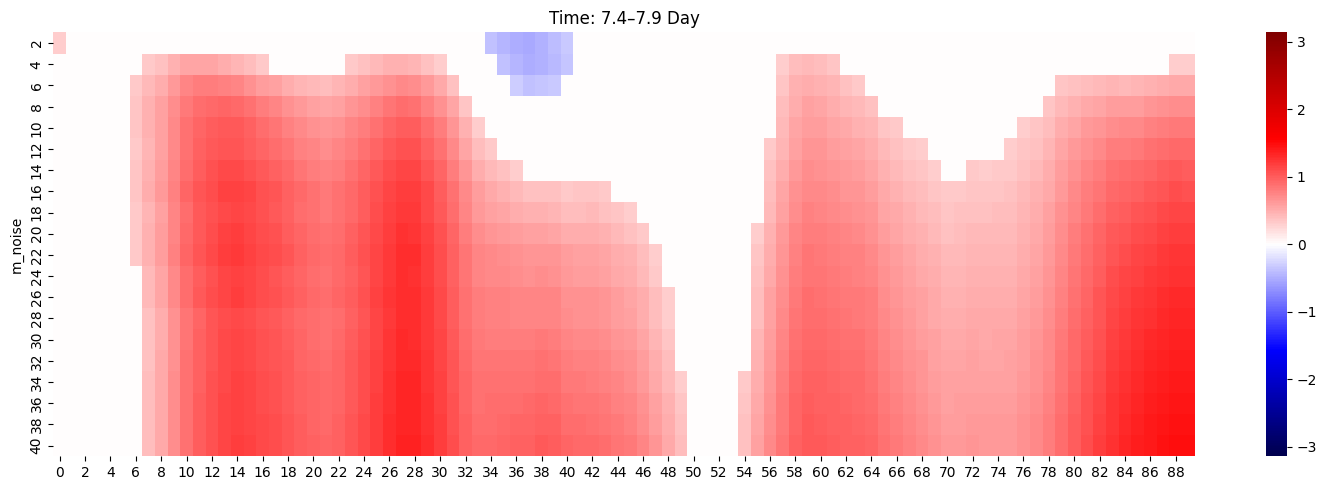

In [59]:
W = 120

threshold = 0.3
delta_ext = np.where(np.abs(alignment_error) < threshold, 0, alignment_error)

plt.figure(figsize=(15, 5))
sns.heatmap(
    delta_ext,
    yticklabels=acc3,
    cmap='seismic',
    center=0,
    vmin=-np.pi,
    vmax=np.pi,
    cbar=True
)
plt.ylabel("m_noise")
plt.title(f"Time: {t*dt/24 :.1f}–{(t+W)*dt/24 :.1f} Day")
plt.tight_layout()

plt.show()

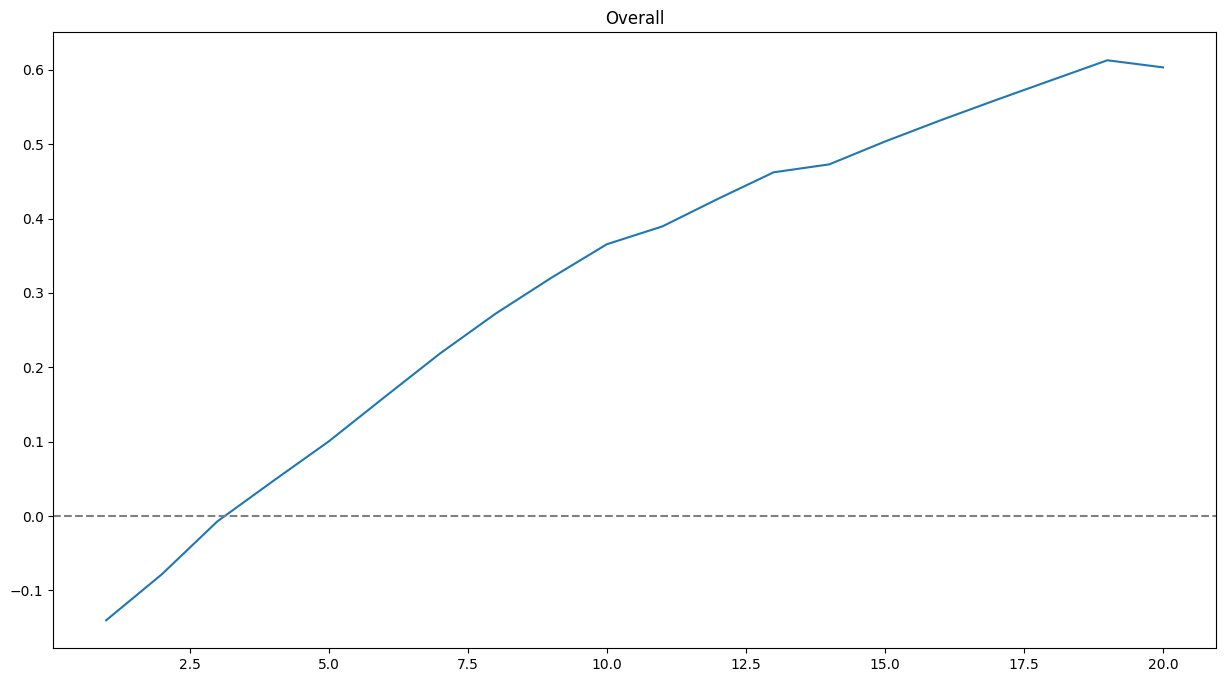

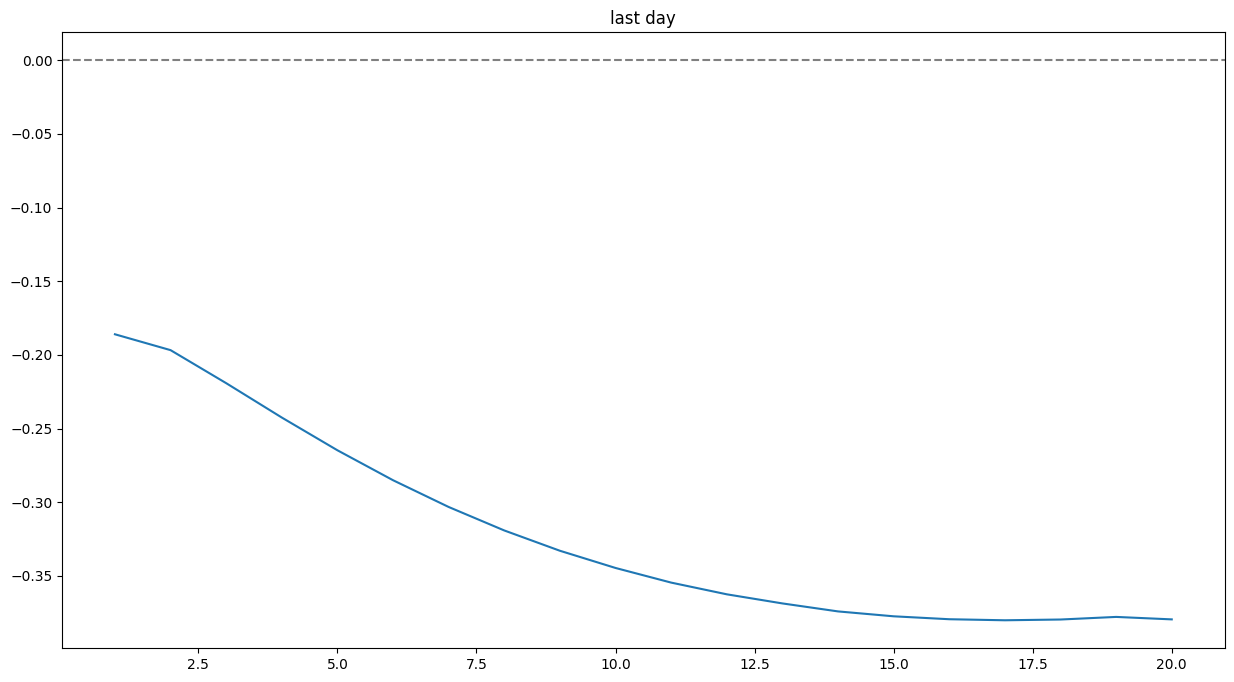

In [20]:
plt.figure(figsize=(15,8))
plt.plot(acc3, np.mean(MN, axis=1))
plt.axhline(y=0, linestyle='--', color='gray')
plt.title('Overall')


plt.figure(figsize=(15,8))
plt.plot(acc3, np.mean(MN[:,-240:], axis=1))
plt.axhline(y=0, linestyle='--', color='gray')
plt.title('last day');

Population Size

simulating9/9: 100%|████████████████████████| 1200/1200 [06:02<00:00,  3.31it/s]


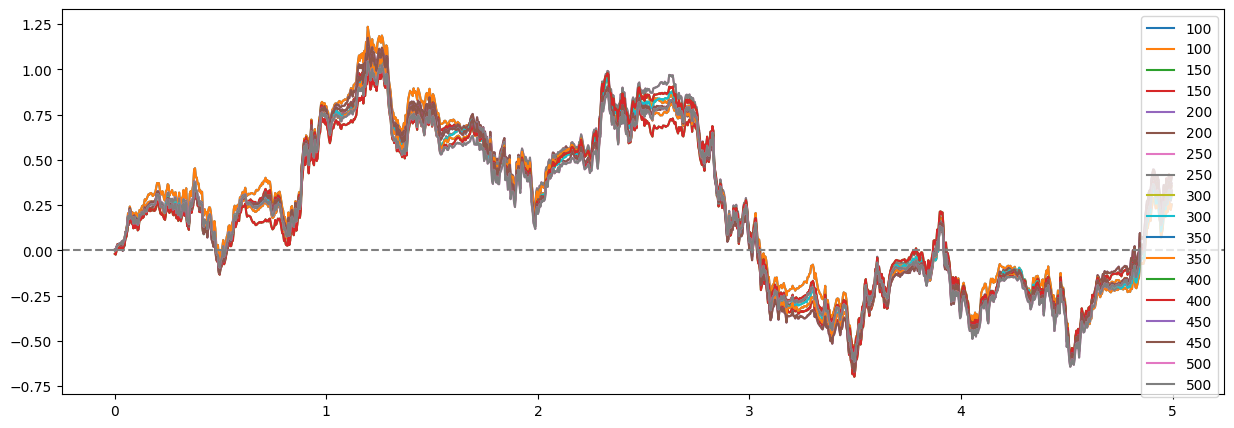

In [10]:
np.random.seed(200)

acc3=np.arange(100, 550, 50)


T = 24*5 ; dt = 0.1 ; timesteps = np.arange(0, T, dt) ; duration=len(timesteps)
PS = np.zeros((len(acc3), duration))

P_prime=0.5

kappa_p_prime = 1 / P_prime**2 if P_prime > 0 else 0
init_cov = 0.1

P=0
M=7

s,m = sm_simulation(T=T, dt=dt, P=P, M=M)

n=0
plt.figure(figsize=(15,5))
for N in acc3:
    mean_period=23.5
    std_period = 0.2


    var_p = P_prime**2
    var_m = M**2

    var_prior=np.zeros(duration)
    var_post=np.zeros(duration)
    G=np.zeros((len(acc3), N, duration))

    K_matrix = np.random.uniform(0, 2, (N, N))
    K_matrix = (K_matrix + K_matrix.T) / 2
    np.fill_diagonal(K_matrix, 0)

    ################## SCN filter init ###################
    phase_history = np.zeros((N, duration))
    psi = np.zeros(duration)
    r  = np.zeros(duration)


    # von Mises sample
    omega = np.abs(np.random.normal(loc=2 * np.pi / mean_period, scale=(2 * np.pi / mean_period**2)*std_period, size=N))
    xi = np.random.vonmises(mu=0, kappa=kappa_p_prime, size=(duration, N)) if P_prime > 0 else np.zeros((duration, N))

    for t in tqdm(range(duration), desc=f"simulating{n+1}/{len(acc3)}", ncols=80):

        if t==0:
            phases = np.random.normal(loc=0, scale=0.1, size=N)

            var_prev=init_cov 
        else:
            var_prev=var_post[t-1]
        
        phase_history[:, t]=phases

        order_param = np.mean(np.exp(1j * phases)); '->np.mean(complex number) = np.ang + np.abs'
        r[t] = np.abs(order_param)
        psi[t] = np.angle(order_param)


        var_prior[t] = var_prev + var_p
        inv_var_post = 1 / var_prior[t] + 1 / var_m
        var_post[t] = 1 / inv_var_post   

        if t < (duration-1):

            for i in range(N):

                H = np.cos(phases[i]+omega[i])
                gap = m[t]-np.sin(phases[i]+omega[i])
                G[n,i,t] = H*var_prior[t]/ (H*var_prior[t]*H + var_m)
       
                coupling_sum = 0
                for j in range(N):
                    coupling_sum += K_matrix[i,j] * np.sin(phases[j] - phases[i])

                phases[i] += (omega[i] + xi[t,i] + G[n,i,t]*gap + (1/N)*coupling_sum) * dt
        
            phases = np.mod(phases+np.pi, 2 * np.pi)-np.pi
    delta = psi-s
    delta = np.mod(delta+np.pi, 2 * np.pi)-np.pi
    plt.plot(timesteps/24, delta, label=f'{N}')
    plt.plot(timesteps/24, np.unwrap(delta), label=f'{N}')

    PS[n, :]=delta
    n+=1
plt.axhline(y=0, linestyle='--', color='gray')
plt.legend()
plt.show()

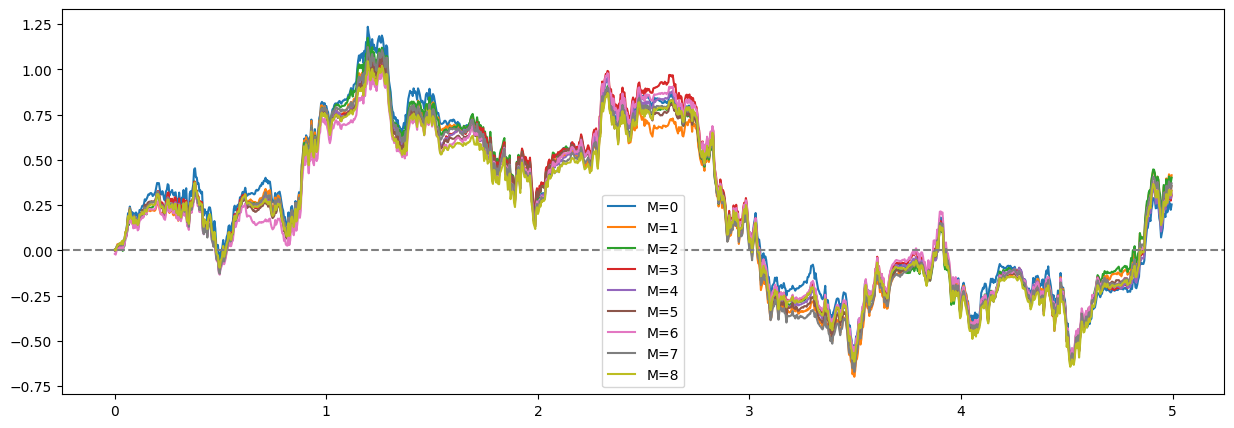

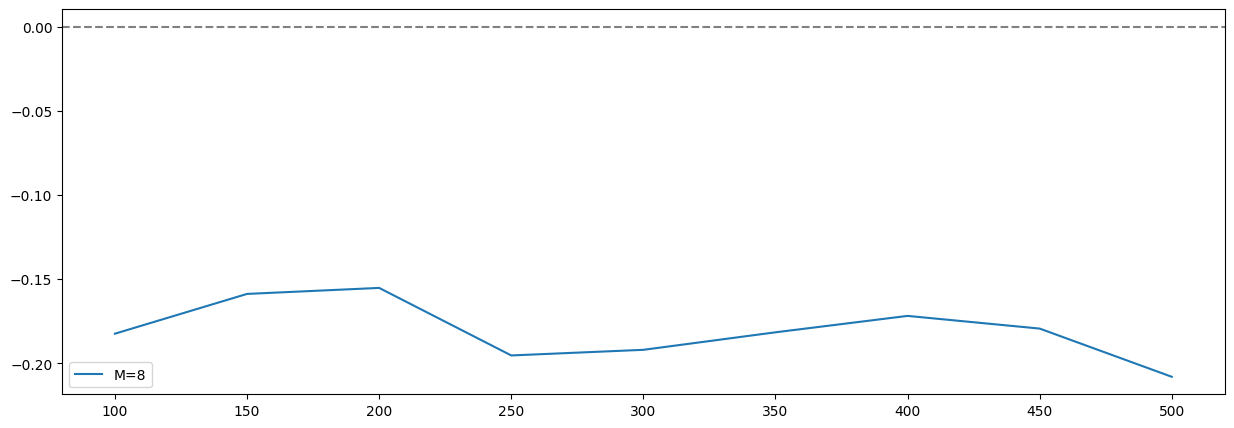

In [14]:
plt.figure(figsize=(15,5))
for i in range(9):
    plt.plot(timesteps/24, PS[i], label=f'M={i}')
plt.axhline(y=0, linestyle='--', color='gray')
plt.legend()
plt.show()

plt.figure(figsize=(15,5))
plt.plot(acc3, np.mean(PS[:,-240:], axis=1), label=f'M={i}')
plt.axhline(y=0, linestyle='--', color='gray')
plt.legend()
plt.show()